# Mahalanobis OOD Detection on GTSRB (MobileNetV1 backbone)

Fork of `notebook.ipynb` (the canonical V2 notebook) with the backbone swapped to `timm.mobilenetv1_100`. The training checkpoint is reused from `notebook_mobilenetv1.ipynb` (saved at `checkpoints/mobilenetv1_gtsrb_best.pth`).

**Sections**
- §2 In-Domain (GTSRB): config, model load, accuracy report, per-layer feature extraction, per-class Gaussian fit.
- §3 Out-of-Domain analysis: per-layer Mahalanobis AUROC / ROC / score histograms against Tiny-ImageNet and Oxford-IIIT Pet, then multi-layer combiners (mean_z, uniform_sum, logreg-FGSM, custom top-K).
- §4 Near-OOD (held-out GTSRB classes): retrain V1 on 38 of 43 classes, treat the 5 held-out classes as OOD, evaluate per-layer and combined.

Out of scope here: V2's §5 (Oxford-as-ID) -- handled in the separate `notebook_mobilenetv1_oxford.ipynb`.


## 1. Configuration


In [1]:
import os, sys, time, json, random, urllib.request, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import GTSRB
import timm
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# ---- paths
DATA_DIR = "data"
CKPT_DIR = "checkpoints"
CACHE_DIR = "cache_v1"   # namespaced so V1 features don't collide with V2 caches
CKPT_PATH = os.path.join(CKPT_DIR, "mobilenetv1_gtsrb_best.pth")
for d in (DATA_DIR, CKPT_DIR, CACHE_DIR):
    os.makedirs(d, exist_ok=True)

# ---- training control
TRAIN_FROM_SCRATCH = False  # set True to force a retrain even if a checkpoint exists
EPOCHS = 8
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
SEED = 0

# ---- data + model
MODEL_NAME = "mobilenetv1_100"   # timm; uses the ra4_e3600_r224_in1k checkpoint
NUM_CLASSES = 43                  # GTSRB has 43 sign classes
IMG_SIZE = 224                    # timm V1 native input size
NORM_MEAN = [0.5, 0.5, 0.5]      # timm V1 ra4 recipe -- do NOT use ImageNet stats
NORM_STD = [0.5, 0.5, 0.5]

# 14 hook points: stem (bn1) + 13 DepthwiseSeparableConv blocks flattened across timm's 5 stages.
LAYERS = list(range(14))
LAYER_NAMES = [f"block{i}" for i in LAYERS]

# Per-layer spatial pool size before flatten. 1 = global average pool.
# Larger k preserves more spatial info, useful for early layers where channels are few.
# V1 spatial map per block:
#   block0..1 -> 112x112, block2..3 -> 56x56, block4..5 -> 28x28,
#   block6..11 -> 14x14,  block12..13 -> 7x7
POOL_SIZES = {f"block{i}": (4 if i <= 3 else 2 if i <= 11 else 1) for i in LAYERS}

# ---- feature pooling
# Spatial-pool mode used inside FeatureHooks. "avg" matches the original behavior.
# "softmax" uses softmax-weighted spatial pooling (Filip's variant).
M_DISTANCE_POOLING = "avg"

# ---- OOD eval split sizes
N_ID_VAL, N_ID_TEST = 1000, 5000
N_OOD_TEST = 5000

# ---- determinism
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = (torch.device("mps")  if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))
print("device:", DEVICE)
print("checkpoint exists:", os.path.exists(CKPT_PATH))


c:\Users\thijm\anaconda3\envs\ISTseminar\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
checkpoint exists: True


## 2. In-Domain (GTSRB)

Full pipeline for the in-distribution data: dataset, transforms, model, training, evaluation, feature extraction, and Gaussian fit.

### Data

Downloads GTSRB into `./data/`.


In [2]:
print("--> GTSRB train"); GTSRB(root=DATA_DIR, split="train", download=True)
print("--> GTSRB test");  GTSRB(root=DATA_DIR, split="test", download=True)
print("data ready")

--> GTSRB train
--> GTSRB test
data ready


### Transforms

Mild augmentation for training, deterministic transform for eval.


In [3]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05),
                            scale=(0.9, 1.1), shear=5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

### Model

MobileNetV2 with the final linear replaced by a 43-way head. The backbone is initialized from ImageNet-pretrained weights.

In [4]:
def build_model(pretrained=True, num_classes=NUM_CLASSES):
    return timm.create_model(MODEL_NAME, pretrained=pretrained, num_classes=num_classes)


### Training

Skipped if `TRAIN_FROM_SCRATCH=False` and a checkpoint exists. Stratified 90/10 split, AdamW + cosine LR, 8 epochs, batch 64, save best by val accuracy. Per-epoch history is stored inside the checkpoint.


In [5]:
def train_model():
    full_train_aug = GTSRB(root=DATA_DIR, split="train", transform=train_tf, download=False)
    full_train_eval = GTSRB(root=DATA_DIR, split="train", transform=eval_tf, download=False)
    labels = np.array([lbl for _, lbl in full_train_aug._samples])
    rng = np.random.default_rng(SEED)
    train_idx, val_idx = [], []
    for c in np.unique(labels):
        idx = np.where(labels == c)[0]; rng.shuffle(idx)
        n_val = max(1, int(round(0.1 * len(idx))))
        val_idx.extend(idx[:n_val].tolist()); train_idx.extend(idx[n_val:].tolist())
    train_idx = np.array(train_idx); val_idx = np.array(val_idx)
    print(f"train={len(train_idx)}  val={len(val_idx)}  classes={len(np.unique(labels))}",
          flush=True)

    train_ds = Subset(full_train_aug, train_idx)
    val_ds = Subset(full_train_eval, val_idx)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    model = build_model(pretrained=True).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    @torch.no_grad()
    def evaluate(loader):
        model.eval()
        correct = total = 0; loss_sum = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        return correct / total, loss_sum / total

    history, best_val = [], 0.0
    for epoch in range(EPOCHS):
        model.train()
        t0 = time.time()
        running_loss = running_correct = running_total = 0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x); loss = criterion(out, y)
            loss.backward(); optimizer.step()
            running_loss    += loss.item() * x.size(0)
            running_correct += (out.argmax(1) == y).sum().item()
            running_total   += y.size(0)
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  ep{epoch+1} step {i+1}/{len(train_loader)} "
                      f"loss={running_loss/running_total:.4f} "
                      f"acc={running_correct/running_total:.4f}", flush=True)
        scheduler.step()
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_acc, val_loss = evaluate(val_loader)
        print(f"epoch {epoch+1}/{EPOCHS}  train_acc={train_acc:.4f}  "
              f"val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}  ({time.time()-t0:.1f}s)",
              flush=True)
        history.append({"epoch": epoch+1, "train_loss": train_loss,
                        "train_acc": train_acc, "val_loss": val_loss,
                        "val_acc": val_acc})
        if val_acc > best_val:
            best_val = val_acc
            torch.save({"model_state_dict": model.state_dict(),
                        "epoch": epoch+1, "val_acc": val_acc,
                        "best_val_acc": val_acc,
                        "train_idx": train_idx.tolist(),
                        "val_idx":   val_idx.tolist(),
                        "history": list(history)}, CKPT_PATH)
            print(f"  ↳ saved best ({val_acc:.4f}) to {CKPT_PATH}", flush=True)
    print(f"\nDONE  best_val_acc={best_val:.4f}")

if TRAIN_FROM_SCRATCH or not os.path.exists(CKPT_PATH):
    train_model()
else:
    print(f"checkpoint found at {CKPT_PATH} , skipping training")

checkpoint found at checkpoints\mobilenetv1_gtsrb_best.pth , skipping training


### Loaded model


In [6]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
model = build_model(pretrained=False)
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(DEVICE).eval()

train_idx = np.asarray(ckpt["train_idx"])
val_idx = np.asarray(ckpt["val_idx"])
print(f"loaded checkpoint  epoch={ckpt['epoch']}  best_val_acc={ckpt['val_acc']:.4f}")
print(f"split sizes: train={len(train_idx)}  val={len(val_idx)}")

loaded checkpoint  epoch=8  best_val_acc=1.0000
split sizes: train=23976  val=2664


### Training curves

Train and val loss/accuracy per epoch from the checkpoint history.


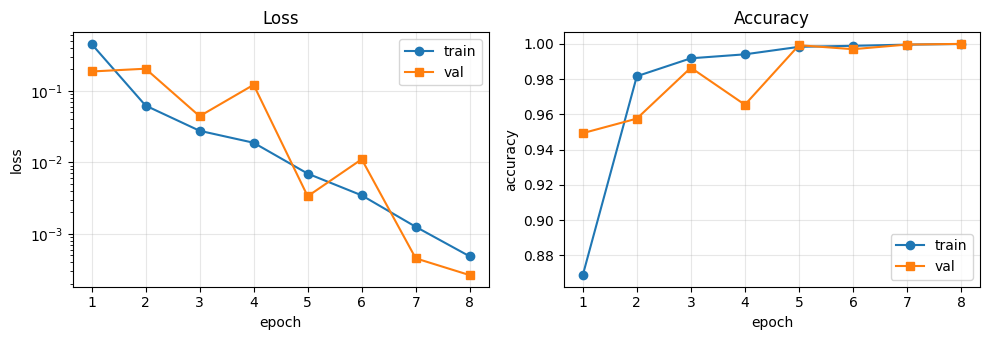

In [7]:
hist = ckpt.get("history")
if hist:
    epochs = [h["epoch"] for h in hist]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    ax1.plot(epochs, [h["train_loss"] for h in hist], "-o", label="train")
    ax1.plot(epochs, [h["val_loss"]   for h in hist], "-s", label="val")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.set_yscale("log")
    ax1.set_title("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(epochs, [h["train_acc"] for h in hist], "-o", label="train")
    ax2.plot(epochs, [h["val_acc"]   for h in hist], "-s", label="val")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
    ax2.set_title("Accuracy"); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print("no history in checkpoint (older format)")

### Accuracy on held-out val and on the official test set


In [8]:
gtsrb_train_eval = GTSRB(root=DATA_DIR, split="train", transform=eval_tf)
gtsrb_test = GTSRB(root=DATA_DIR, split="test", transform=eval_tf)

@torch.no_grad()
def accuracy(loader):
    correct = total = 0
    for x, y in loader:
        x = x.to(DEVICE)
        correct += (model(x).argmax(1).cpu() == y).sum().item()
        total += y.size(0)
    return correct / total

# Val acc was recorded during training and stored in the checkpoint, no recompute needed.
modelval_acc = ckpt["val_acc"]

# Cache test accuracy: deterministic, so we only ever compute it once.
test_acc_path = os.path.join(CACHE_DIR, "gtsrb_test_acc_v1ood.json")
if os.path.exists(test_acc_path):
    test_acc = json.load(open(test_acc_path))["test_acc"]
else:
    test_acc = accuracy(DataLoader(gtsrb_test, batch_size=128, num_workers=0))
    with open(test_acc_path, "w") as f:
        json.dump({"test_acc": test_acc}, f)

print(f"GTSRB model-val top-1 (random 10% of train, leaky): {modelval_acc:.4f}")
print(f"GTSRB official test  top-1 (different signs entirely): {test_acc:.4f}")

GTSRB model-val top-1 (random 10% of train, leaky): 1.0000
GTSRB official test  top-1 (different signs entirely): 0.9906


### Feature extraction

Hook all 19 MobileNetV2 blocks, pool the spatial maps (per-layer pool size
from `POOL_SIZES`), cache to `./cache/`.


In [9]:
def _v1_layer_modules(m):
    """Ordered (name, module) list of hook points for timm mobilenetv1_100.
    14 points: stem (bn1) then every DepthwiseSeparableConv across the 5 stages."""
    out = [("block0", m.bn1)]
    i = 1
    for stage in m.blocks:
        for dsconv in stage:
            out.append((f"block{i}", dsconv))
            i += 1
    return out

class FeatureHooks:
    """Attach forward hooks; collect pooled features (B,C) per named layer.
    `pooling`: "avg" (default) or "softmax" (softmax-weighted spatial pooling)."""
    def __init__(self, model, pooling="avg"):
        self.pooling = pooling
        self.features = {}
        self._handles = []
        for name, mod in _v1_layer_modules(model):
            self._handles.append(mod.register_forward_hook(self._hook(name)))
    def _hook(self, name):
        def fn(_, __, out):
            if out.dim() == 4:
                if self.pooling == "avg":
                    k = POOL_SIZES.get(name, 1)
                    if k <= 1:
                        out = out.mean(dim=(2, 3))                     # global avg pool
                    else:
                        out = F.adaptive_avg_pool2d(out, k).flatten(1) # spatial-grid avg pool
                elif self.pooling == "softmax":
                    B, C, H, W = out.shape
                    spatial = out.view(B, C, -1)                       # (B, C, H*W)
                    weights = F.softmax(spatial, dim=-1)
                    out = (spatial * weights).sum(dim=-1)              # (B, C)
                else:
                    raise ValueError(f"unknown pooling mode: {self.pooling}")
            self.features[name] = out
        return fn
    def remove(self):
        for h in self._handles: h.remove()

hooks = FeatureHooks(model, pooling=M_DISTANCE_POOLING)

def loader(ds, batch=128):
    return DataLoader(ds, batch_size=batch, shuffle=False, num_workers=0)

@torch.no_grad()
def extract(ds, also_logits=False, labels_too=False):
    feats = {n: [] for n in LAYER_NAMES}
    logits, labels = [], []
    for batch in loader(ds):
        x, y = batch
        x = x.to(DEVICE)
        out = model(x)
        for n in LAYER_NAMES:
            feats[n].append(hooks.features[n].detach().cpu().numpy())
        if also_logits: logits.append(out.detach().cpu().numpy())
        if labels_too: labels.append(np.asarray(y))
    feats = {k: np.concatenate(v, 0) for k, v in feats.items()}
    out = {"features": feats}
    if also_logits: out["logits"] = np.concatenate(logits, 0)
    if labels_too:  out["labels"] = np.concatenate(labels, 0)
    return out

def extract_cached(name, ds, also_logits=False, labels_too=False):
    suffix = "" if M_DISTANCE_POOLING == "avg" else f"_{M_DISTANCE_POOLING}"
    path = os.path.join(CACHE_DIR, f"{name}{suffix}.npz")
    if os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        out = {"features": {k.replace("feat_", ""): d[k] for k in d.files if k.startswith("feat_")}}
        if "logits" in d.files: out["logits"] = d["logits"]
        if "labels" in d.files: out["labels"] = d["labels"]
        print(f"  load  {name}.npz")
        return out
    print(f"  extract {name} ({len(ds)} samples)", flush=True)
    t0 = time.time()
    out = extract(ds, also_logits=also_logits, labels_too=labels_too)
    save = {f"feat_{k}": v for k, v in out["features"].items()}
    if "logits" in out: save["logits"] = out["logits"]
    if "labels" in out: save["labels"] = out["labels"]
    np.savez_compressed(path, **save)
    print(f"  done in {time.time()-t0:.1f}s")
    return out


In [10]:
gtsrb_fit_ds = Subset(gtsrb_train_eval, train_idx)

rng = np.random.default_rng(1)
perm_id = rng.permutation(len(gtsrb_test))[:N_ID_VAL + N_ID_TEST]
id_val_ds = Subset(gtsrb_test, perm_id[:N_ID_VAL])
id_test_ds = Subset(gtsrb_test, perm_id[N_ID_VAL:])

print("extracting features ...")
fit_out = extract_cached("fit", gtsrb_fit_ds, labels_too=True)
id_test_out = extract_cached("id_test", id_test_ds, also_logits=True, labels_too=True)

print("\nlayer dims:")
for n in LAYER_NAMES:
    print(f"  {n}: dim={fit_out['features'][n].shape[1]}  "
          f"N_fit={fit_out['features'][n].shape[0]}")

extracting features ...
  load  fit.npz
  load  id_test.npz

layer dims:
  block0: dim=512  N_fit=23976
  block1: dim=1024  N_fit=23976
  block2: dim=2048  N_fit=23976
  block3: dim=2048  N_fit=23976
  block4: dim=1024  N_fit=23976
  block5: dim=1024  N_fit=23976
  block6: dim=2048  N_fit=23976
  block7: dim=2048  N_fit=23976
  block8: dim=2048  N_fit=23976
  block9: dim=2048  N_fit=23976
  block10: dim=2048  N_fit=23976
  block11: dim=2048  N_fit=23976
  block12: dim=1024  N_fit=23976
  block13: dim=1024  N_fit=23976


### Per-class Gaussians (tied covariance)

Per-class mean plus one shared covariance, matching Eq. 1 of the report.


In [11]:
def fit_gaussian(feats, labels, num_classes, shrink=0.1):
    """Per-class means and a single tied covariance (Eq. 1 of the report)
    with Ledoit-Wolf-style shrinkage for numerical conditioning at high-D layers."""
    feats = np.asarray(feats, dtype=np.float64)
    D = feats.shape[1]
    means = np.zeros((num_classes, D))
    centered = []
    for c in range(num_classes):
        m = feats[labels == c]
        if len(m) == 0: continue
        mu = m.mean(axis=0); means[c] = mu
        centered.append(m - mu)
    centered = np.concatenate(centered, axis=0)
    cov = (centered.T @ centered) / centered.shape[0]
    target = (np.trace(cov) / D) * np.eye(D)
    cov = (1 - shrink) * cov + shrink * target
    return means.astype(np.float32), np.linalg.inv(cov).astype(np.float32)

gaussians = {}
fit_labels = fit_out["labels"]
for n in LAYER_NAMES:
    means, prec = fit_gaussian(fit_out["features"][n], fit_labels, NUM_CLASSES)
    gaussians[n] = (means, prec)
    print(f"  {n}: means {means.shape}  precision {prec.shape}")

  block0: means (43, 512)  precision (512, 512)
  block1: means (43, 1024)  precision (1024, 1024)
  block2: means (43, 2048)  precision (2048, 2048)
  block3: means (43, 2048)  precision (2048, 2048)
  block4: means (43, 1024)  precision (1024, 1024)
  block5: means (43, 1024)  precision (1024, 1024)
  block6: means (43, 2048)  precision (2048, 2048)
  block7: means (43, 2048)  precision (2048, 2048)
  block8: means (43, 2048)  precision (2048, 2048)
  block9: means (43, 2048)  precision (2048, 2048)
  block10: means (43, 2048)  precision (2048, 2048)
  block11: means (43, 2048)  precision (2048, 2048)
  block12: means (43, 1024)  precision (1024, 1024)
  block13: means (43, 1024)  precision (1024, 1024)


## 3. Out-of-Domain Analysis

All OOD evaluations below share the same machinery: per-layer Mahalanobis
scoring against the fitted Gaussians, the same ID test split, the same
metrics. Helpers are defined once in the next cell; every OOD source
calls `analyze_ood_source(...)`. Adding a new source is one cell.

Mahalanobis score:

$$
\text{score}(x) \;=\; \min_{c}\; \bigl(f(x) - \hat{\mu}_c\bigr)^{\!\top}\, \hat{\Sigma}^{-1}\, \bigl(f(x) - \hat{\mu}_c\bigr)
$$

Lower means more in-distribution. Same as Lee et al. Eq. 2 (and Eq. 2 in
the report), with the outer minus sign dropped.


In [12]:
# --- Shared scoring helpers (used for every OOD source below) ---

def mahalanobis_min(feats, means, precision):
    feats = np.asarray(feats, dtype=np.float64)
    means = np.asarray(means, dtype=np.float64)
    P = np.asarray(precision, dtype=np.float64)
    Px = feats @ P
    Pmu = means @ P
    quad_x = np.einsum("nd,nd->n", Px, feats)
    quad_mu = np.einsum("cd,cd->c", Pmu, means)
    cross = Px @ means.T
    return (quad_x[:, None] + quad_mu[None, :] - 2.0 * cross).min(axis=1)

def metric_set(scores_id, scores_ood, higher_is_more_id=True):
    s_id = -scores_id if higher_is_more_id else scores_id
    s_ood = -scores_ood if higher_is_more_id else scores_ood
    y = np.concatenate([np.zeros_like(s_id), np.ones_like(s_ood)])
    s = np.concatenate([s_id, s_ood])
    auroc = roc_auc_score(y, s)
    thr = np.quantile(s_id, 0.95)
    tnr95 = float((s_ood > thr).mean())
    grid = np.quantile(s, np.linspace(0, 1, 1001))
    best = 0.0
    for t in grid:
        best = max(best, 0.5 * ((s_ood >= t).mean() + (s_id < t).mean()))
    return {"auroc": float(auroc), "tnr@95": tnr95, "det_acc": float(best)}

def score_layer(n, feats):
    means, prec = gaussians[n]
    return mahalanobis_min(feats, means, prec)

class OODWrapper(Dataset):
    """Wrap any (image, label) dataset to return (image, 0). Optional subsampling."""
    def __init__(self, base, n=None, seed=0):
        if n is None or n >= len(base):
            self.idx = np.arange(len(base))
        else:
            rng = np.random.default_rng(seed)
            self.idx = rng.permutation(len(base))[:n]
        self.base = base
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        x, _ = self.base[int(self.idx[i])]
        return x, 0

def evaluate_ood_source(ood_ds, name):
    """Per-layer Mahalanobis metrics for any OOD dataset. Caches features under
    `cache/ood_test_{name}.npz`. Returns dict with per_layer, md_ood."""
    ood_out = extract_cached(f"ood_test_{name}", ood_ds, also_logits=True)
    md_ood = {n: score_layer(n, ood_out["features"][n]) for n in LAYER_NAMES}
    per_layer_metrics = {n: metric_set(md_id_test[n], md_ood[n], higher_is_more_id=False)
                         for n in LAYER_NAMES}
    return {"per_layer": per_layer_metrics, "md_ood": md_ood}

def _print_per_layer_table(result):
    pl = result["per_layer"]
    print(f"{'layer':10s}  {'AUROC':>7s}  {'TNR@95':>7s}  {'DetAcc':>7s}")
    for n in LAYER_NAMES:
        m = pl[n]
        print(f"{n:10s}  {m['auroc']:.4f}   {m['tnr@95']:.4f}   {m['det_acc']:.4f}")

def _plot_bar(result, display_name):
    pl = result["per_layer"]
    vals = [pl[n]["auroc"] for n in LAYER_NAMES]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.bar(LAYER_NAMES, vals, color="steelblue")
    ax.set_ylim(0.5, 1.005); ax.set_ylabel("AUROC")
    ax.set_title(f"Mahalanobis AUROC per block, OOD = {display_name}")
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, 0.51, f"{v:.3f}", ha="center", va="bottom",
                fontsize=8.5, rotation=90, color="white", fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

def _plot_roc(result, display_name):
    from sklearn.metrics import roc_curve
    colors = plt.cm.tab20(np.linspace(0, 1, len(LAYER_NAMES)))
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    for n, color in zip(LAYER_NAMES, colors):
        sid = md_id_test[n]; sood = result["md_ood"][n]
        y = np.r_[np.zeros(len(sid)), np.ones(len(sood))]
        s = np.r_[sid, sood]                                  # higher distance = more OOD-like
        fpr, tpr, _ = roc_curve(y, s)
        ax.plot(fpr, tpr, color=color, lw=1.3, label=n)
    ax.plot([0, 1], [0, 1], "k--", lw=0.5)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC curves per block, OOD = {display_name}")
    ax.legend(loc="lower right", ncol=2, fontsize=7)
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_score_distribution(result, display_name, n_top=4):
    """Score-distribution histograms at the top n_top layers (sorted by AUROC desc)."""
    pl = result["per_layer"]
    top = sorted(LAYER_NAMES, key=lambda n: pl[n]["auroc"], reverse=True)[:n_top]
    ncols = 2
    nrows = (n_top + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.0 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, bl in zip(axes, top):
        sid = md_id_test[bl]; sood = result["md_ood"][bl]
        lo, hi = float(min(sid.min(), sood.min())), float(max(sid.max(), sood.max()))
        bins = np.linspace(lo, hi, 60)
        ax.hist(sid, bins=bins, alpha=0.6, color="steelblue", label=f"ID, n={len(sid)}")
        ax.hist(sood, bins=bins, alpha=0.6, color="darkorange", label=f"OOD, n={len(sood)}")
        ax.set_xlabel(f"Mahalanobis distance at {bl}")
        ax.set_ylabel("count")
        ax.set_title(f"{bl}  AUROC={pl[bl]['auroc']:.4f}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    for ax in axes[len(top):]:
        ax.axis("off")
    fig.suptitle(f"Score distributions at top {n_top} layers, OOD = {display_name}")
    plt.tight_layout(); plt.show()

def analyze_ood_source(ood_ds, name, display_name=None):
    """End-to-end per-layer OOD analysis: scoring + table + bar + ROC + histogram.
    Returns the result dict (per_layer, md_ood)."""
    display_name = display_name or name
    result = evaluate_ood_source(ood_ds, name)
    _print_per_layer_table(result)
    _plot_bar(result, display_name)
    _plot_roc(result, display_name)
    _plot_score_distribution(result, display_name)
    return result

# Reference ID scores, computed once and reused by every OOD evaluation
md_id_test = {n: score_layer(n, id_test_out["features"][n]) for n in LAYER_NAMES}

### Multi-layer combination

Each block in MobileNetV2 produces its own Mahalanobis score for an image. The single-layer analysis above picks one block and ignores the rest. Here we try the opposite: collapse the per-block scores into one number per image and ask whether that beats the best individual block.

The blocks disagree on scale (`block18` distances are ~1000x `block0`'s), so before combining we z-score each block using the clean-ID distribution at that block. After z-scoring, 0 means "typical for ID", positive means "further than typical". Three combiners:

- `mean_z` -- average the z-scored per-block distances. Unsupervised, every block weighted equally.
- `uniform_sum` -- sum instead of mean (same ranking, kept as a sanity check).
- `logreg_fgsm` -- the paper's recipe. Fit a logistic regression to tell clean ID images apart from FGSM-perturbed copies of those same ID images, using the per-block distances as features. The regression learns a weight per block; useless blocks get a weight near zero. No OOD data is used anywhere -- FGSM gives us a stand-in for "weird inputs" generated from ID alone.

Layer presets passed to the combiners:

- `LAYER_NAMES` -- all 19 blocks.
- `STAGE_LAYERS` -- the 5 MobileNetV2 stage boundaries (`block1, 3, 6, 13, 18`); analogous to "one feature per ResNet stage" in the paper.

Unweighted averages get hurt by uninformative blocks, so `mean_z` uses the smaller stage subset. `logreg_fgsm` learns its own weights, so it gets all 19.

In [13]:
# --- Multi-layer combiners + FGSM tuning (no OOD data is used to fit or tune) ---
from sklearn.linear_model import LogisticRegression

STAGE_LAYERS = ["block1", "block3", "block5", "block11", "block13"]   # MobileNetV1 stage outputs (timm)

def _stack_md(md_dict, layers):
    return np.stack([md_dict[n] for n in layers], axis=1)              # (N, L)

def id_layer_stats(md_id, layers):
    M = _stack_md(md_id, layers)
    return M.mean(axis=0), M.std(axis=0) + 1e-12

def combine_mean_z(md_eval, layers, id_stats):
    mu, sd = id_stats
    return ((_stack_md(md_eval, layers) - mu) / sd).mean(axis=1)

def combine_uniform_sum(md_eval, layers, id_stats):
    mu, sd = id_stats
    return ((_stack_md(md_eval, layers) - mu) / sd).sum(axis=1)

def combine_logreg(md_eval, layers, lr):
    return lr.decision_function(_stack_md(md_eval, layers))            # higher = more OOD-like

def fgsm_md(ds, tag, eps, batch=64):
    """Score every LAYER_NAMES on clean and FGSM-perturbed copies of `ds`.
    Caches MD scores (not features) under cache/fgsm_{tag}_eps{eps}.npz."""
    suffix = "" if M_DISTANCE_POOLING == "avg" else f"_{M_DISTANCE_POOLING}"
    path = os.path.join(CACHE_DIR, f"fgsm_{tag}{suffix}_eps{eps:.4f}.npz")
    if os.path.exists(path):
        d = np.load(path)
        md_clean = {n: d[f"clean_{n}"] for n in LAYER_NAMES}
        md_adv = {n: d[f"adv_{n}"]   for n in LAYER_NAMES}
        print(f"  load  fgsm_{tag}.npz")
        return md_clean, md_adv
    print(f"  FGSM tune  tag={tag}  eps={eps}  n={len(ds)}", flush=True)
    model.eval()
    clean_feats = {n: [] for n in LAYER_NAMES}
    adv_feats = {n: [] for n in LAYER_NAMES}
    for x, y in DataLoader(ds, batch_size=batch, shuffle=False, num_workers=0):
        x = x.to(DEVICE); y = y.to(DEVICE)
        with torch.no_grad():
            _ = model(x)
            for n in LAYER_NAMES:
                clean_feats[n].append(hooks.features[n].detach().cpu().numpy())
        x_adv = x.clone().detach().requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = (x_adv + eps * grad.sign()).detach()
        with torch.no_grad():
            _ = model(x_adv)
            for n in LAYER_NAMES:
                adv_feats[n].append(hooks.features[n].detach().cpu().numpy())
    clean_feats = {n: np.concatenate(v, 0) for n, v in clean_feats.items()}
    adv_feats = {n: np.concatenate(v, 0) for n, v in adv_feats.items()}
    md_clean = {n: score_layer(n, clean_feats[n]) for n in LAYER_NAMES}
    md_adv = {n: score_layer(n, adv_feats[n])   for n in LAYER_NAMES}
    save = {}
    for n in LAYER_NAMES:
        save[f"clean_{n}"] = md_clean[n]; save[f"adv_{n}"] = md_adv[n]
    np.savez_compressed(path, **save)
    return md_clean, md_adv

def fit_logreg_fgsm(md_clean, md_adv, layers):
    X = np.vstack([_stack_md(md_clean, layers), _stack_md(md_adv, layers)])
    y = np.r_[np.zeros(len(md_clean[layers[0]])), np.ones(len(md_adv[layers[0]]))]
    return LogisticRegression(C=1.0, max_iter=2000).fit(X, y)

def _print_combined_table(rows, display_name):
    print(f"\nMulti-layer combination, OOD = {display_name}")
    print(f"{'method':28s}  {'AUROC':>7s}  {'TNR@95':>7s}  {'DetAcc':>7s}")
    for label, a, t, d in rows:
        print(f"{label:28s}  {a:.4f}   {t:.4f}   {d:.4f}")

def _plot_combined_bar(rows, display_name):
    labels = [r[0] for r in rows]
    vals = [r[1] for r in rows]
    fig, ax = plt.subplots(figsize=(9, 3.8))
    colors = ["dimgray"] + ["steelblue"] * (len(rows) - 1)
    ax.bar(labels, vals, color=colors)
    ax.set_ylim(0.5, 1.005); ax.set_ylabel("AUROC")
    ax.set_title(f"AUROC by method, OOD = {display_name}")
    ax.grid(axis="y", alpha=0.3)
    for i, v in enumerate(vals):
        ax.text(i, 0.51, f"{v:.3f}", ha="center", va="bottom",
                fontsize=8.5, rotation=90, color="white", fontweight="bold")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout(); plt.show()

def _plot_combined_roc(rows_scores, display_name):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    colors = ["dimgray"] + list(plt.cm.tab10(np.linspace(0, 1, max(1, len(rows_scores) - 1))))
    for (label, sid, sood, auroc), c in zip(rows_scores, colors):
        y = np.r_[np.zeros(len(sid)), np.ones(len(sood))]
        fpr, tpr, _ = roc_curve(y, np.r_[sid, sood])
        ax.plot(fpr, tpr, color=c, lw=1.4, label=f"{label}  AUROC={auroc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.5)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC: single vs multi-layer, OOD = {display_name}")
    ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

def _plot_combined_score_distribution(rows_scores, display_name):
    n = len(rows_scores)
    ncols = 2
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 3.0 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, (label, sid, sood, auroc) in zip(axes, rows_scores):
        lo, hi = float(min(sid.min(), sood.min())), float(max(sid.max(), sood.max()))
        bins = np.linspace(lo, hi, 60)
        ax.hist(sid, bins=bins, alpha=0.6, color="steelblue", label=f"ID, n={len(sid)}")
        ax.hist(sood, bins=bins, alpha=0.6, color="darkorange", label=f"OOD, n={len(sood)}")
        ax.set_xlabel("score (higher = more OOD-like)")
        ax.set_ylabel("count")
        ax.set_title(f"{label}  AUROC={auroc:.4f}")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(f"Score distributions per method, OOD = {display_name}")
    plt.tight_layout(); plt.show()

def _plot_logreg_weights(lr, layers, display_name):
    weights = lr.coef_[0]
    fig, ax = plt.subplots(figsize=(10, 3.8))
    colors = ["tomato" if w < 0 else "steelblue" for w in weights]
    ax.bar(layers, weights, color=colors)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylabel("logreg weight")
    ax.set_title(f"logreg_fgsm block weights, OOD = {display_name}")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def analyze_combined(ood_result, display_name, tag, eps=0.005, custom_layers=None):
    """Compare best single layer against multi-layer combinations on `ood_result`.
    `tag` namespaces the FGSM cache; pass e.g. "full" or "kept". `custom_layers` is
    an optional list of layer names (e.g. top-K by single-layer AUROC) -- when given,
    mean_z and logreg_fgsm are also evaluated on that subset. Reads module-scope
    `model`, `hooks`, `gaussians`, `md_id_test`, `id_val_ds`."""
    md_clean, md_adv = fgsm_md(id_val_ds, tag=tag, eps=eps)
    stats_stage = id_layer_stats(md_clean, STAGE_LAYERS)
    stats_all = id_layer_stats(md_clean, LAYER_NAMES)
    lr_all = fit_logreg_fgsm(md_clean, md_adv, LAYER_NAMES)

    pl = ood_result["per_layer"]; md_ood = ood_result["md_ood"]
    best = max(LAYER_NAMES, key=lambda n: pl[n]["auroc"])

    presets = [
        ("mean_z (stage)", lambda m: combine_mean_z(m, STAGE_LAYERS, stats_stage)),
        ("mean_z (all)", lambda m: combine_mean_z(m, LAYER_NAMES, stats_all)),
        ("uniform_sum (stage)", lambda m: combine_uniform_sum(m, STAGE_LAYERS, stats_stage)),
        ("logreg_fgsm (all)", lambda m: combine_logreg(m, LAYER_NAMES, lr_all)),
    ]
    if custom_layers:
        cl = list(custom_layers)
        stats_cl = id_layer_stats(md_clean, cl)
        lr_cl = fit_logreg_fgsm(md_clean, md_adv, cl)
        presets += [
            (f"mean_z (custom, {len(cl)})", lambda m, cl=cl, s=stats_cl: combine_mean_z(m, cl, s)),
            (f"logreg_fgsm (custom, {len(cl)})", lambda m, cl=cl, lr=lr_cl:  combine_logreg(m, cl, lr)),
        ]
    rows = [(f"best single ({best})",
             pl[best]["auroc"], pl[best]["tnr@95"], pl[best]["det_acc"])]
    rows_scores = [(f"best single ({best})", md_id_test[best], md_ood[best], pl[best]["auroc"])]
    for label, fn in presets:
        sid = fn(md_id_test); sood = fn(md_ood)
        m = metric_set(sid, sood, higher_is_more_id=False)
        rows.append((label, m["auroc"], m["tnr@95"], m["det_acc"]))
        rows_scores.append((label, sid, sood, m["auroc"]))
    _print_combined_table(rows, display_name)
    _plot_combined_bar(rows, display_name)
    _plot_combined_roc(rows_scores, display_name)
    _plot_combined_score_distribution(rows_scores, display_name)
    _plot_logreg_weights(lr_all, LAYER_NAMES, display_name)
    if custom_layers:
        _plot_logreg_weights(lr_cl, cl, display_name)
    return {"rows": rows, "scores": rows_scores}


### Tiny-ImageNet

Tiny-ImageNet: 5000 images
  load  ood_test_tiny_imagenet.npz
layer         AUROC   TNR@95   DetAcc
block0      0.9037   0.5322   0.8162
block1      0.9493   0.7264   0.8774
block2      0.9729   0.8656   0.9170
block3      0.9862   0.9276   0.9430
block4      0.9817   0.8862   0.9342
block5      0.9782   0.8766   0.9302
block6      0.9727   0.8406   0.9210
block7      0.9763   0.8424   0.9266
block8      0.9770   0.8578   0.9294
block9      0.9724   0.8178   0.9234
block10     0.9712   0.8014   0.9216
block11     0.9753   0.8528   0.9354
block12     0.9904   0.9948   0.9744
block13     0.9907   0.9986   0.9772


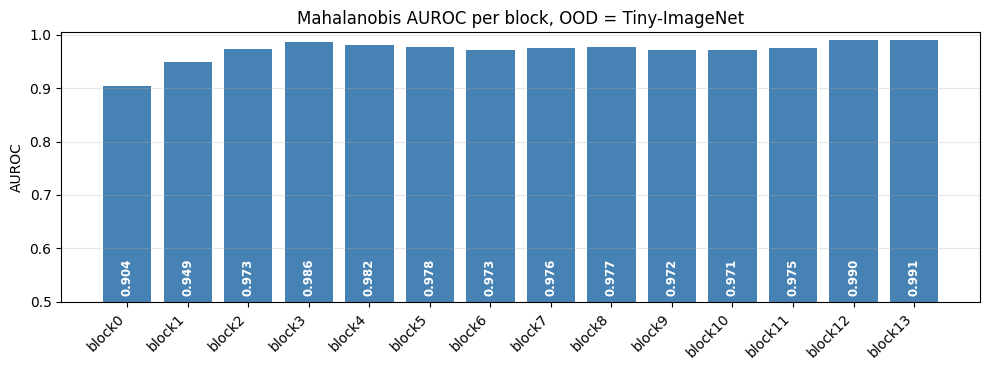

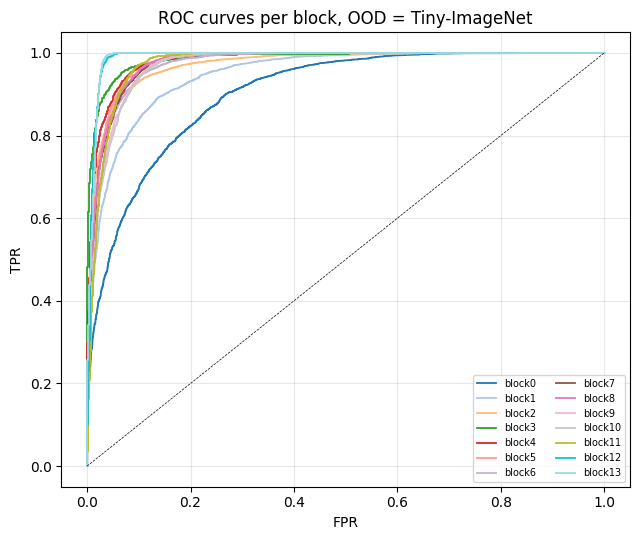

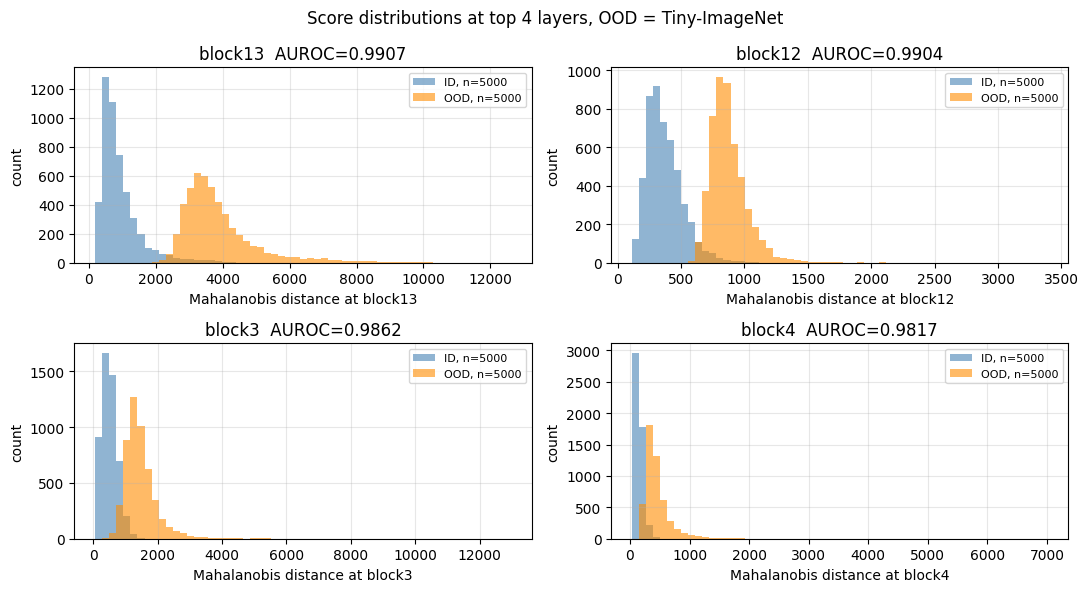

In [14]:
class TinyImageNetFlat(Dataset):
    """Flat reader for Tiny-ImageNet's `train/<wnid>/images/*.JPEG` layout.
    Optional `exclude_wnids` drops semantically in-domain classes (e.g. cat/dog breeds)."""
    def __init__(self, root, transform, exclude_wnids=None):
        exclude_wnids = set(exclude_wnids or [])
        paths = []
        for wnid in sorted(os.listdir(root)):
            if wnid in exclude_wnids:
                continue
            d = os.path.join(root, wnid, "images")
            if not os.path.isdir(d): continue
            for f in sorted(os.listdir(d)):
                if f.lower().endswith(".jpeg"):
                    paths.append(os.path.join(d, f))
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i]).convert("RGB")), 0


def download_tiny_imagenet():
    target = os.path.join(DATA_DIR, "tiny-imagenet-200")
    if os.path.isdir(target):
        return target
    zip_path = os.path.join(DATA_DIR, "tiny-imagenet-200.zip")
    if not os.path.exists(zip_path):
        url = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
        print(f"downloading {url} ...")
        urllib.request.urlretrieve(url, zip_path)
    print("unzipping ...")
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)
    return target


tin_base = TinyImageNetFlat(os.path.join(download_tiny_imagenet(), "train"), transform=eval_tf)
tin_ds = OODWrapper(tin_base, n=N_OOD_TEST, seed=0)
print(f"Tiny-ImageNet: {len(tin_ds)} images")

tin_result = analyze_ood_source(tin_ds, "tiny_imagenet", "Tiny-ImageNet")

  load  fgsm_full.npz

Multi-layer combination, OOD = Tiny-ImageNet
method                          AUROC   TNR@95   DetAcc
best single (block13)         0.9907   0.9986   0.9772
mean_z (stage)                0.9978   0.9964   0.9806
mean_z (all)                  0.9959   0.9902   0.9718
uniform_sum (stage)           0.9978   0.9964   0.9806
logreg_fgsm (all)             0.9234   0.7274   0.8790


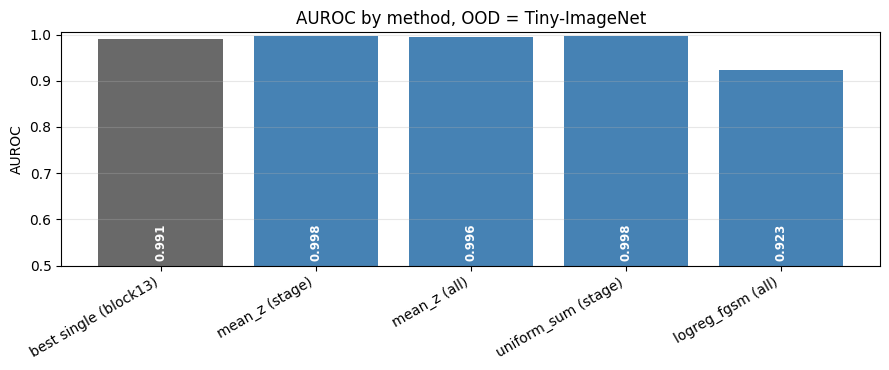

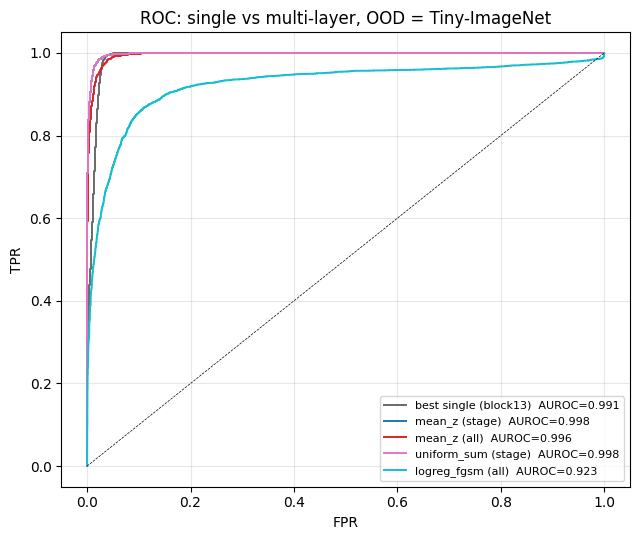

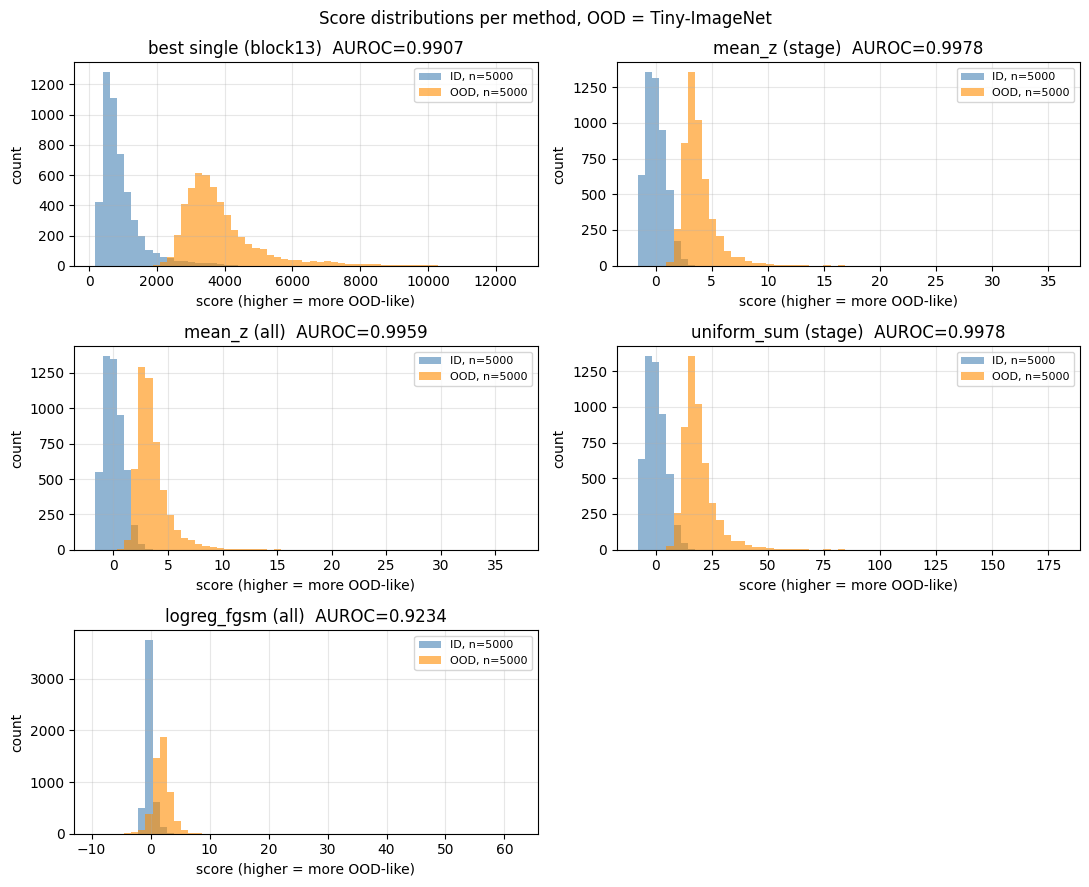

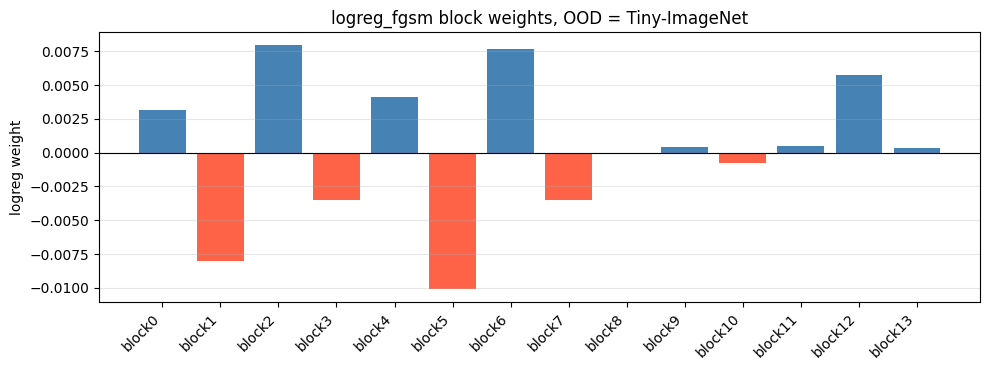

{'rows': [('best single (block13)', 0.99071944, 0.9986, 0.9772000000000001),
  ('mean_z (stage)', 0.9978492400000001, 0.9964, 0.9806),
  ('mean_z (all)', 0.9959174, 0.9902, 0.9718),
  ('uniform_sum (stage)', 0.9978492400000001, 0.9964, 0.9806),
  ('logreg_fgsm (all)', 0.9233841599999999, 0.7274, 0.879)],
 'scores': [('best single (block13)',
   array([ 652.53433443,  415.1219136 ,  692.48529742, ...,  733.04180411,
          1424.21289967, 1064.5903178 ]),
   array([4651.13734395, 2640.8053349 , 3354.28627588, ..., 3567.06575838,
          5507.6265678 , 3851.80147666]),
   0.99071944),
  ('mean_z (stage)',
   array([ 0.21416954, -0.63711658,  0.40450382, ...,  0.2932609 ,
          -0.00395354,  0.47847896]),
   array([3.90694726, 3.28797055, 3.33089114, ..., 3.07258673, 3.47853174,
          4.2568044 ]),
   0.9978492400000001),
  ('mean_z (all)',
   array([ 0.12897504, -0.73211614,  0.43114301, ...,  0.26883081,
          -0.03427292,  0.49637167]),
   array([3.27173265, 3.33552353,

In [15]:
analyze_combined(tin_result, "Tiny-ImageNet", tag="full")

  load  fgsm_full.npz

Multi-layer combination, OOD = Tiny-ImageNet
method                          AUROC   TNR@95   DetAcc
best single (block13)         0.9907   0.9986   0.9772
mean_z (stage)                0.9978   0.9964   0.9806
mean_z (all)                  0.9959   0.9902   0.9718
uniform_sum (stage)           0.9978   0.9964   0.9806
logreg_fgsm (all)             0.9234   0.7274   0.8790
mean_z (custom, 5)            0.9984   0.9986   0.9844
logreg_fgsm (custom, 5)       0.9213   0.7176   0.8810


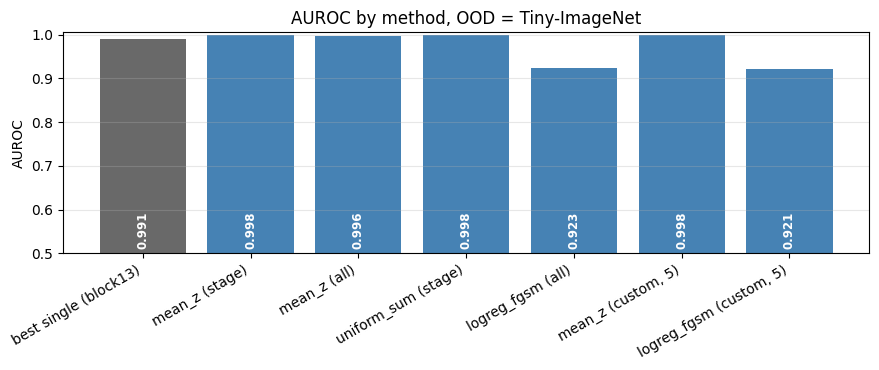

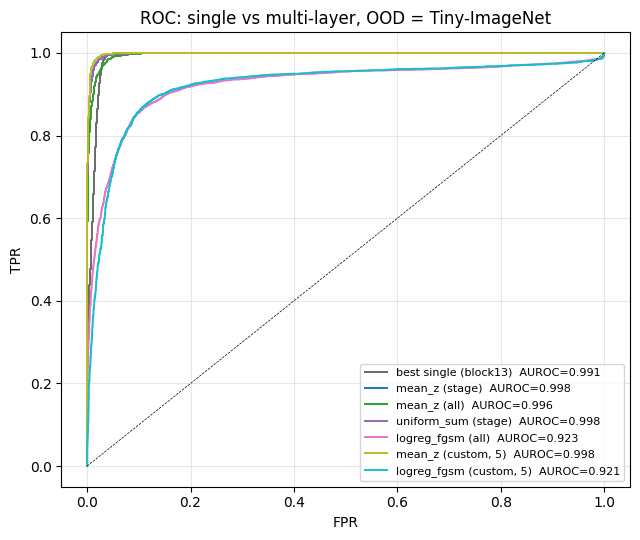

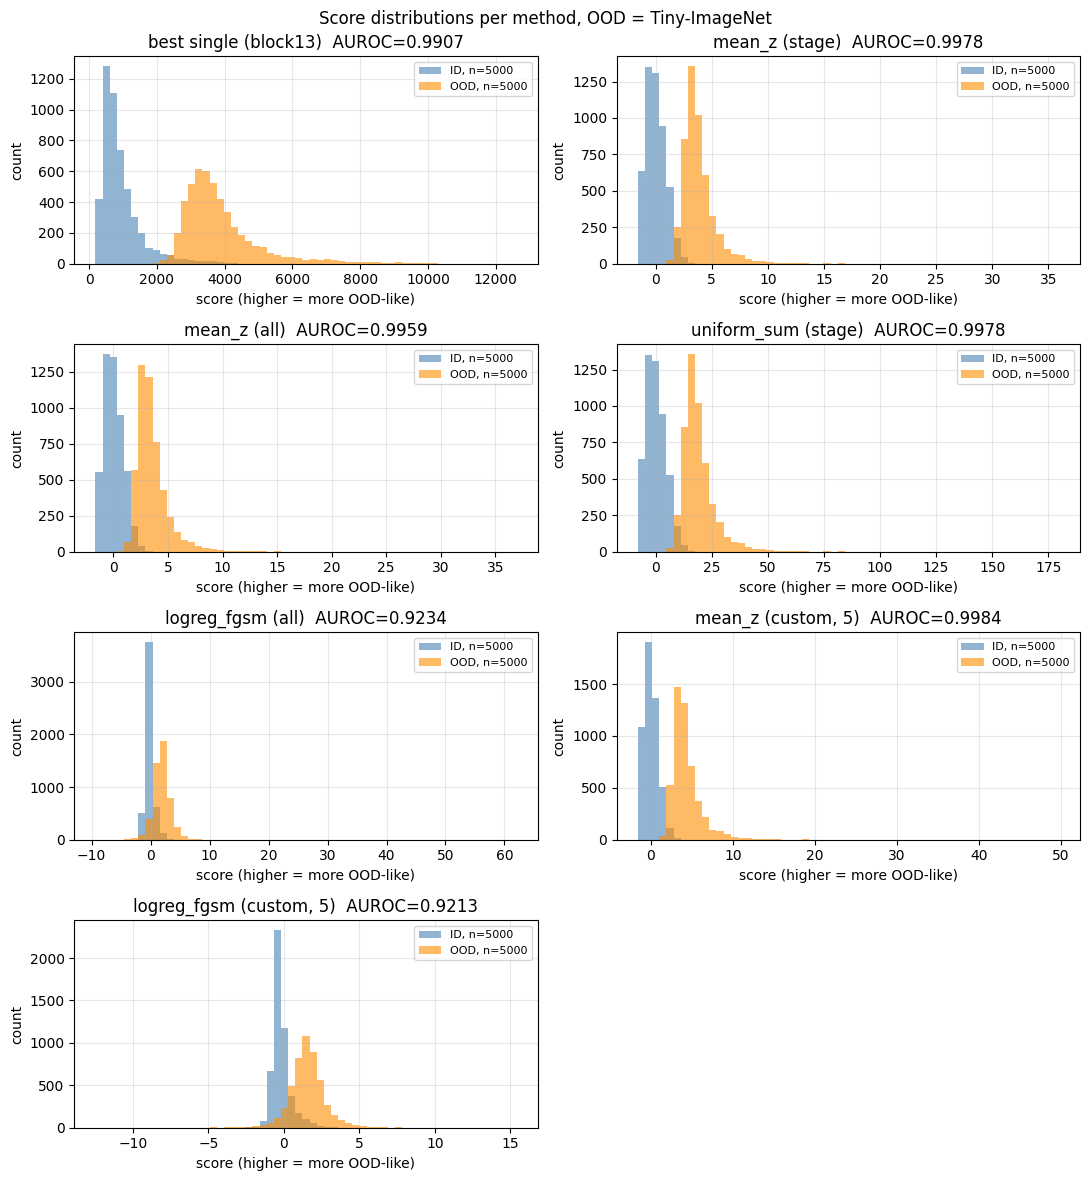

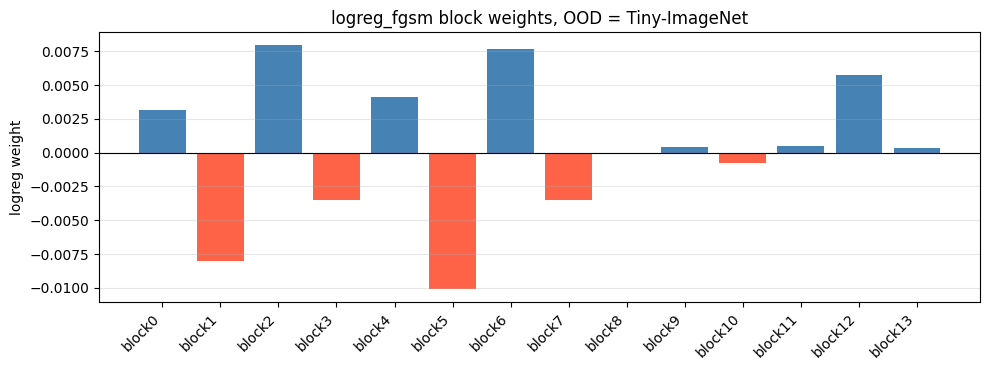

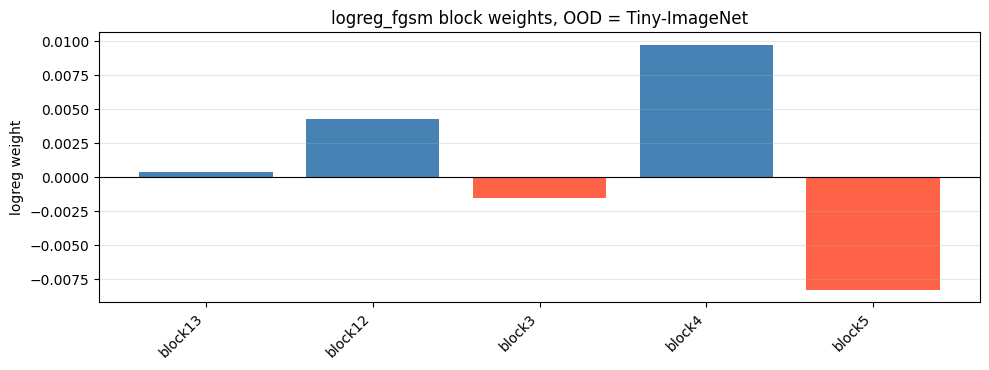

{'rows': [('best single (block13)', 0.99071944, 0.9986, 0.9772000000000001),
  ('mean_z (stage)', 0.9978492400000001, 0.9964, 0.9806),
  ('mean_z (all)', 0.9959174, 0.9902, 0.9718),
  ('uniform_sum (stage)', 0.9978492400000001, 0.9964, 0.9806),
  ('logreg_fgsm (all)', 0.9233841599999999, 0.7274, 0.879),
  ('mean_z (custom, 5)', 0.99841112, 0.9986, 0.9843999999999999),
  ('logreg_fgsm (custom, 5)', 0.92131164, 0.7176, 0.881)],
 'scores': [('best single (block13)',
   array([ 652.53433443,  415.1219136 ,  692.48529742, ...,  733.04180411,
          1424.21289967, 1064.5903178 ]),
   array([4651.13734395, 2640.8053349 , 3354.28627588, ..., 3567.06575838,
          5507.6265678 , 3851.80147666]),
   0.99071944),
  ('mean_z (stage)',
   array([ 0.21416954, -0.63711658,  0.40450382, ...,  0.2932609 ,
          -0.00395354,  0.47847896]),
   array([3.90694726, 3.28797055, 3.33089114, ..., 3.07258673, 3.47853174,
          4.2568044 ]),
   0.9978492400000001),
  ('mean_z (all)',
   array([ 0.1

In [16]:
top5 = sorted(LAYER_NAMES, key=lambda n: tin_result["per_layer"][n]["auroc"], reverse=True)[:5]
analyze_combined(tin_result, "Tiny-ImageNet", tag="full", custom_layers=top5)

### Oxford-IIIT Pet

Oxford Pets: 3680 images
  load  ood_test_oxford_pets.npz
layer         AUROC   TNR@95   DetAcc
block0      0.9074   0.4910   0.8316
block1      0.9567   0.7443   0.8910
block2      0.9826   0.9092   0.9362
block3      0.9873   0.9323   0.9456
block4      0.9792   0.8726   0.9316
block5      0.9688   0.8005   0.9163
block6      0.9587   0.7340   0.9017
block7      0.9596   0.7041   0.9090
block8      0.9636   0.7486   0.9172
block9      0.9607   0.7242   0.9130
block10     0.9629   0.7402   0.9125
block11     0.9681   0.7970   0.9264
block12     0.9852   0.9886   0.9698
block13     0.9880   0.9989   0.9774


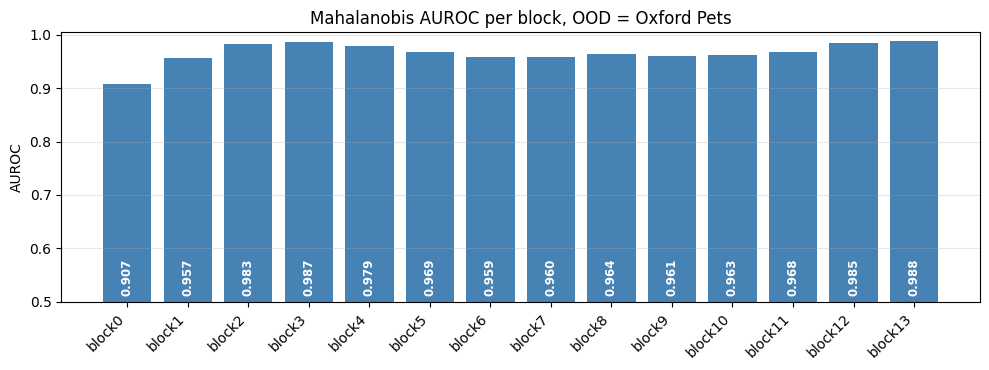

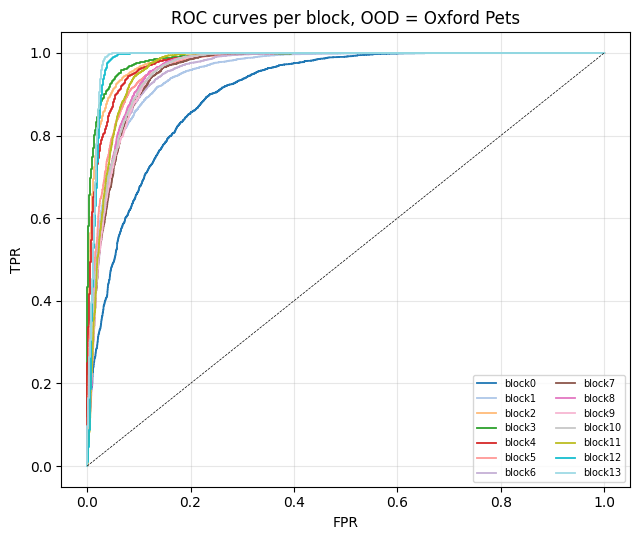

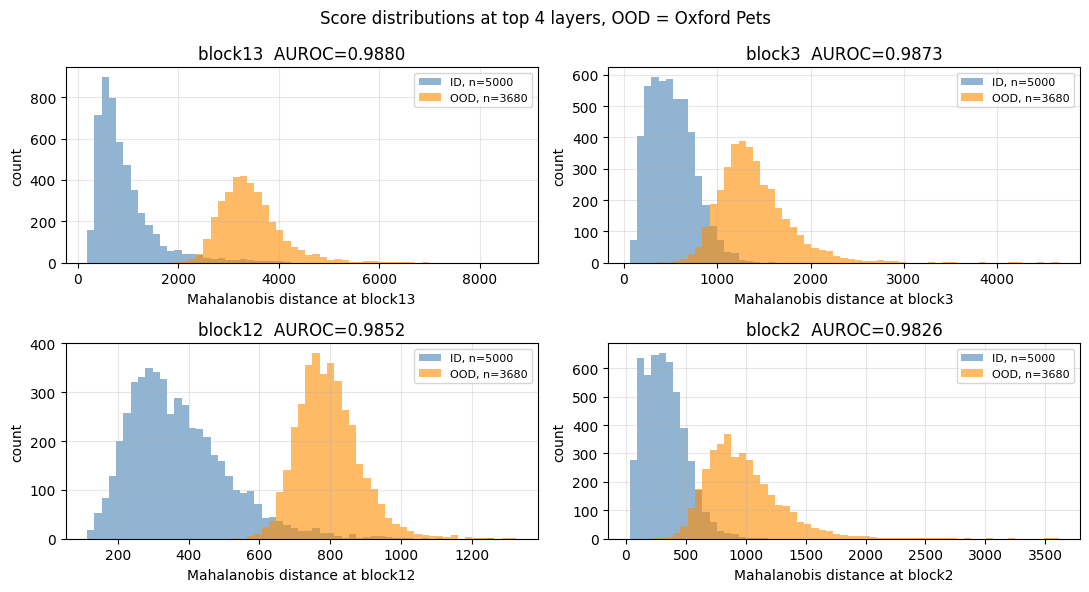

In [17]:
from torchvision.datasets import OxfordIIITPet

pets_base = OxfordIIITPet(root=DATA_DIR, split="trainval", target_types="category",
                          transform=eval_tf, download=True)
pets_ds = OODWrapper(pets_base, n=N_OOD_TEST, seed=0)
print(f"Oxford Pets: {len(pets_ds)} images")

pets_result = analyze_ood_source(pets_ds, "oxford_pets", "Oxford Pets")

  load  fgsm_full.npz

Multi-layer combination, OOD = Oxford Pets
method                          AUROC   TNR@95   DetAcc
best single (block13)         0.9880   0.9989   0.9774
mean_z (stage)                0.9968   0.9943   0.9779
mean_z (all)                  0.9938   0.9826   0.9672
uniform_sum (stage)           0.9968   0.9943   0.9779
logreg_fgsm (all)             0.9640   0.8356   0.9174


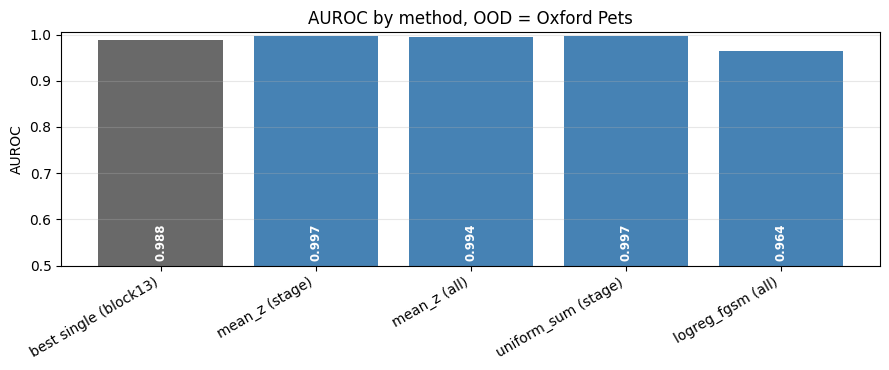

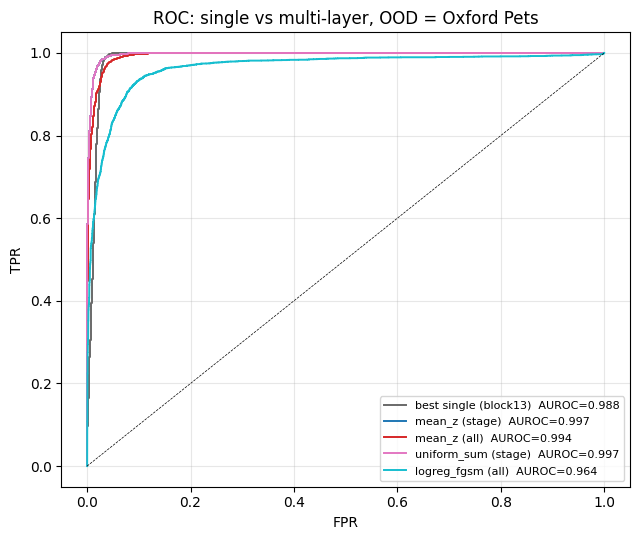

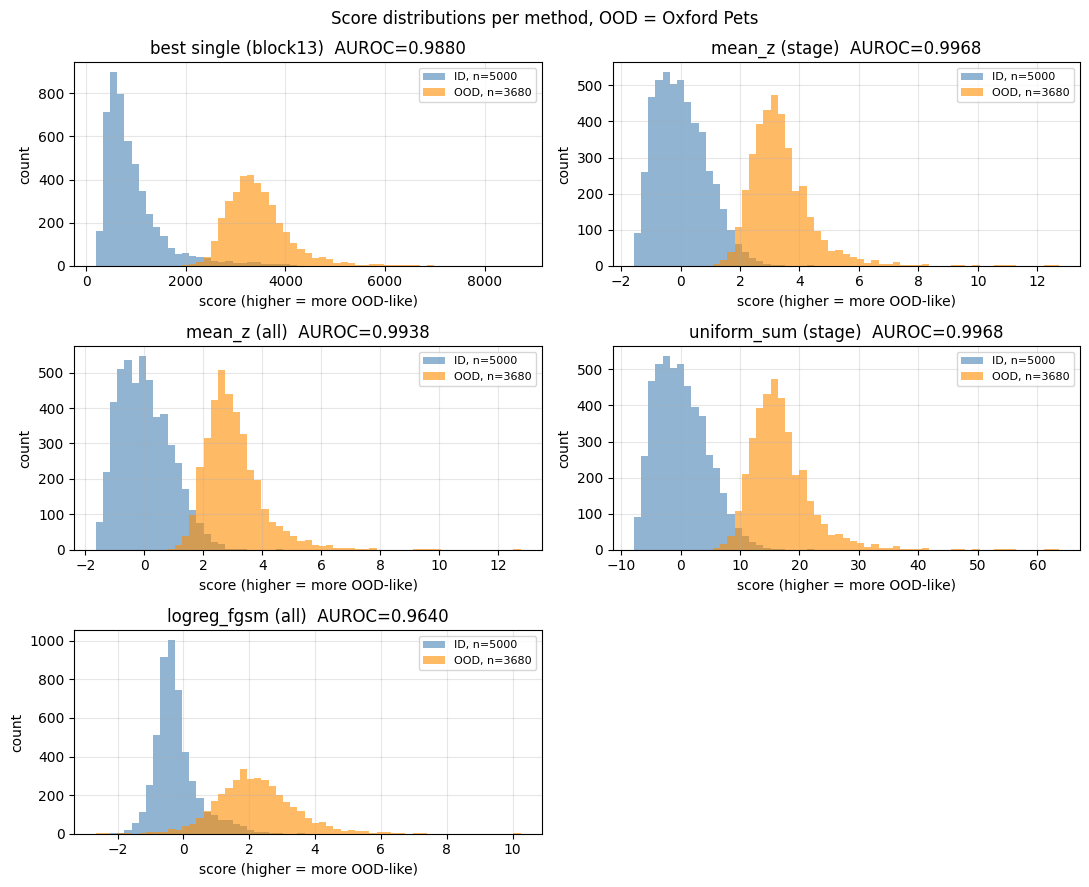

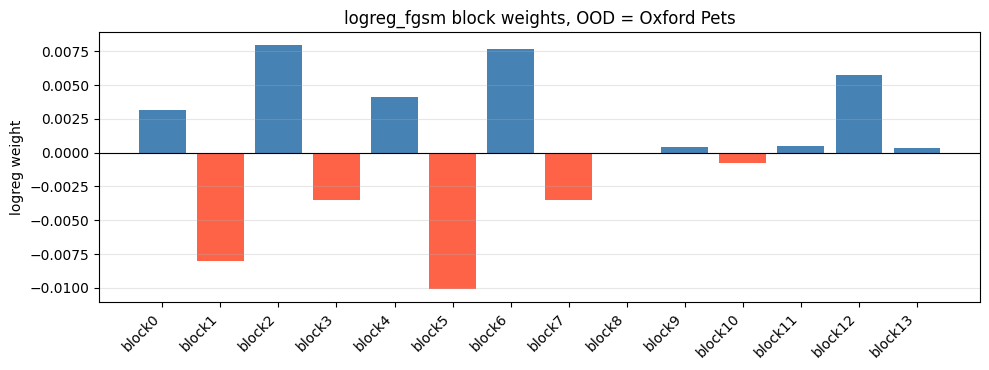

{'rows': [('best single (block13)',
   0.9879504347826087,
   0.9989130434782608,
   0.9773728260869565),
  ('mean_z (stage)',
   0.9967648369565217,
   0.9942934782608696,
   0.9779478260869565),
  ('mean_z (all)', 0.9938173369565216, 0.9826086956521739, 0.9672304347826087),
  ('uniform_sum (stage)',
   0.9967648369565217,
   0.9942934782608696,
   0.9779478260869565),
  ('logreg_fgsm (all)',
   0.9639708152173914,
   0.8355978260869565,
   0.9174347826086957)],
 'scores': [('best single (block13)',
   array([ 652.53433443,  415.1219136 ,  692.48529742, ...,  733.04180411,
          1424.21289967, 1064.5903178 ]),
   array([3331.17554507, 4166.24907645, 4716.78710548, ..., 4103.94636041,
          3009.63966161, 3443.1254517 ]),
   0.9879504347826087),
  ('mean_z (stage)',
   array([ 0.21416954, -0.63711658,  0.40450382, ...,  0.2932609 ,
          -0.00395354,  0.47847896]),
   array([4.38416268, 4.34235184, 3.97303846, ..., 3.64847932, 3.30768784,
          4.60652035]),
   0.996764

In [18]:
analyze_combined(pets_result, "Oxford Pets", tag="full")

## 4. Near-OOD: held-out GTSRB classes

The Tiny-ImageNet and Oxford-Pets results above are saturated (AUROC > 0.99 at most layers).

For a more challenging benchmark we construct a *near-OOD* split: retrain MobileNetV1 on a subset of the 43 GTSRB classes, then treat the held-out classes as OOD.

### 4.1 Class inventory

Before picking holdouts we look at sample counts and visual structure across the 43 GTSRB classes. The split needs to satisfy two constraints:

1. Held-out classes must have enough samples for a useful OOD test pool.
2. Held-out classes must not be visually idiosyncratic --> if the only octagonal sign is held out, the detector exploits shape alone and the benchmark re-saturates.

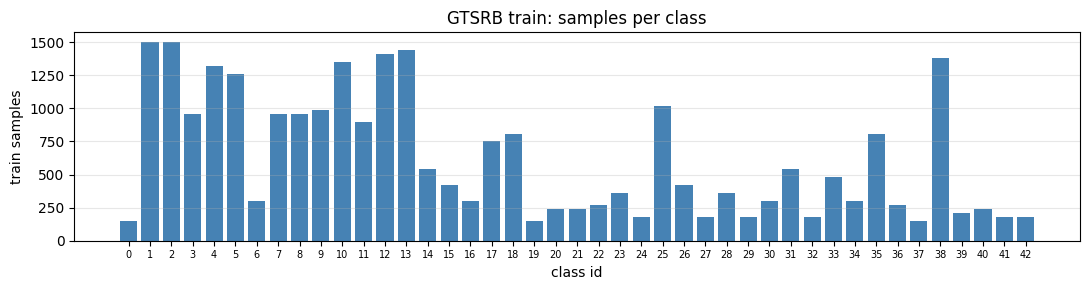

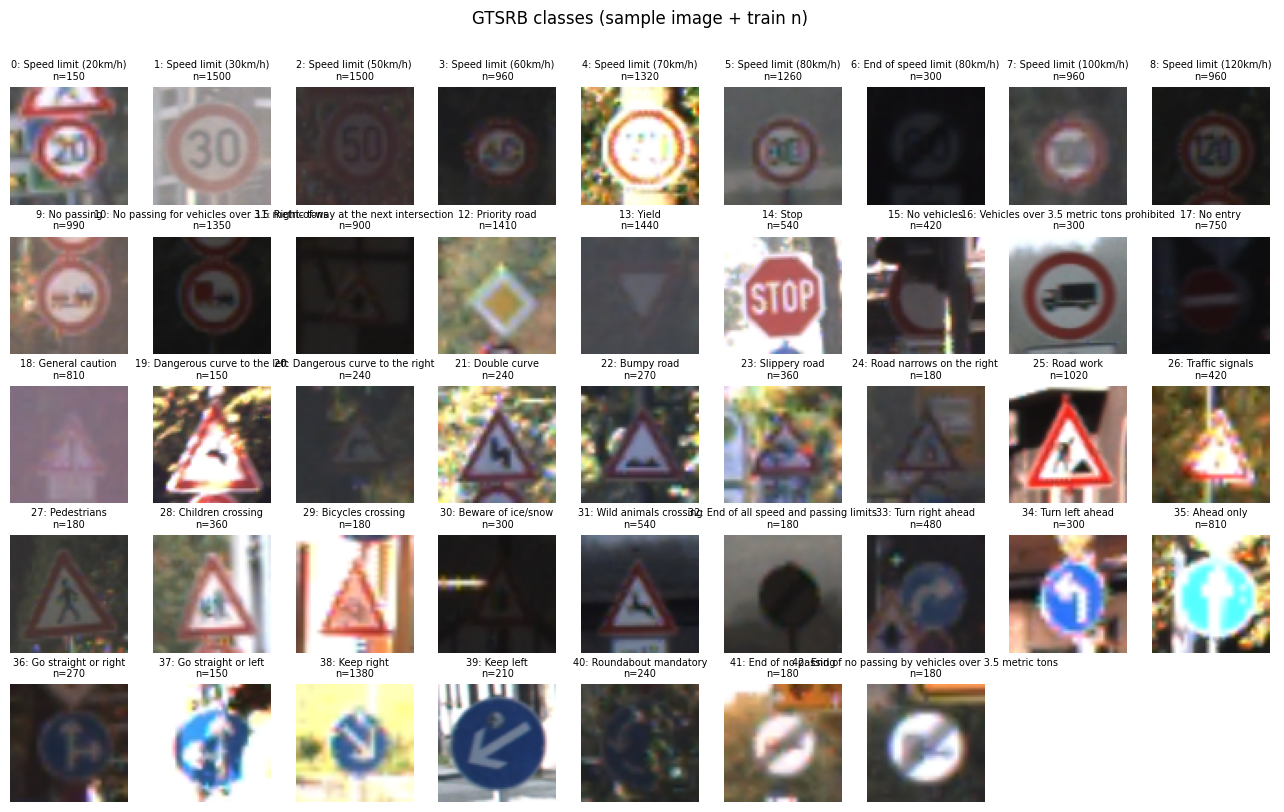

In [19]:
SIGNNAMES_URL = "https://raw.githubusercontent.com/udacity/CarND-Traffic-Sign-Classifier-Project/master/signnames.csv"
SIGNNAMES_PATH = os.path.join(DATA_DIR, "gtsrb_signnames.csv")
if not os.path.exists(SIGNNAMES_PATH):
    urllib.request.urlretrieve(SIGNNAMES_URL, SIGNNAMES_PATH)
CLASS_NAMES = pd.read_csv(SIGNNAMES_PATH).set_index("ClassId")["SignName"].to_dict()

gtsrb_train_labels_all = np.array([lbl for _, lbl in gtsrb_train_eval._samples])
class_counts = np.bincount(gtsrb_train_labels_all, minlength=NUM_CLASSES)

# Samples per class
fig, ax = plt.subplots(figsize=(11, 3))
ax.bar(range(NUM_CLASSES), class_counts, color="steelblue")
ax.set_xlabel("class id"); ax.set_ylabel("train samples")
ax.set_title("GTSRB train: samples per class")
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(range(NUM_CLASSES), fontsize=7)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# One sample image per class (raw, pre-normalization, for visual inspection)
raw_tf = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
gtsrb_train_raw = GTSRB(root=DATA_DIR, split="train", transform=raw_tf)
first_idx = {c: int(np.where(gtsrb_train_labels_all == c)[0][0]) for c in range(NUM_CLASSES)}

fig, axes = plt.subplots(5, 9, figsize=(13, 8))
axes = axes.flatten()
for c in range(NUM_CLASSES):
    img, _ = gtsrb_train_raw[first_idx[c]]
    axes[c].imshow(img.permute(1, 2, 0).numpy())
    axes[c].set_title(f"{c}: {CLASS_NAMES[c]}\nn={class_counts[c]}", fontsize=7)
    axes[c].axis("off")
for c in range(NUM_CLASSES, len(axes)):
    axes[c].axis("off")
plt.suptitle("GTSRB classes (sample image + train n)", y=1.01)
plt.tight_layout(); plt.show()

### 4.2 Holdout selection

Four GTSRB classes are visually idiosyncratic (each is the only sign with its shape) and would let a detector flag them using shape alone. These remain in training:

- 12 Priority road (only diamond)
- 13 Yield (only inverted triangle)
- 14 Stop (only octagon)
- 17 No entry (only red disk with white bar)

We then sample 5 holdouts spanning the three high-volume visual categories so that each holdout has many sibling classes of the same shape and palette still present in training.

| class | name | shape category | role in the split |
|:---:|:---|:---|:---|
| 2  | Speed limit (50km/h) | red-bordered circle, numeric | sibling of the 30/60/70/100/120 km/h signs kept in training |
| 5  | Speed limit (80km/h) | red-bordered circle, numeric | sibling of the 30/60/70/100/120 km/h signs kept in training |
| 25 | Road work            | red-bordered triangle, pictogram | one pictogram amongst many warning triangles kept in training |
| 35 | Ahead only           | blue circle, arrow | one arrow amongst many directional blue circles kept in training |
| 38 | Keep right           | blue circle, arrow | one arrow amongst many directional blue circles kept in training |

The remaining 38 classes are used for training. Total holdout train samples are around 6k, capped at `N_OOD_TEST` for the evaluation pool to match the far-OOD experiments.

In [20]:
HOLDOUT_CLASSES = [2, 5, 25, 35, 38]
KEPT_CLASSES = [c for c in range(NUM_CLASSES) if c not in HOLDOUT_CLASSES]
N_KEPT = len(KEPT_CLASSES)

class KeptClassesDataset(Dataset):
    """Filter a GTSRB-style dataset to a subset of classes; remap labels to 0..K-1."""
    def __init__(self, base, kept_classes):
        all_labels = np.array([lbl for _, lbl in base._samples])
        self.base = base
        self.indices = np.where(np.isin(all_labels, kept_classes))[0]
        self.remap = {orig: new for new, orig in enumerate(sorted(kept_classes))}
        self._kept_labels = all_labels[self.indices]
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        x, y = self.base[int(self.indices[i])]
        return x, self.remap[int(y)]

print(f"holdout classes ({len(HOLDOUT_CLASSES)}):")
for c in HOLDOUT_CLASSES:
    print(f"  {c:>2d}  n_train={class_counts[c]:>4d}  {CLASS_NAMES[c]}")
print(f"\nkept classes: {N_KEPT}   total kept train samples: {int(class_counts[KEPT_CLASSES].sum())}")

holdout classes (5):
   2  n_train=1500  Speed limit (50km/h)
   5  n_train=1260  Speed limit (80km/h)
  25  n_train=1020  Road work
  35  n_train= 810  Ahead only
  38  n_train=1380  Keep right

kept classes: 38   total kept train samples: 20670


### 4.3 Retrain on kept classes

Same recipe as 2: MobileNetV1 from ImageNet weights, stratified 90/10 split on the kept-class subset of GTSRB train, AdamW + cosine LR, 8 epochs, save best by val accuracy. The classification head is sized to `N_KEPT = 38` outputs and labels are remapped to `0..N_KEPT-1` before loss.

In [21]:
KEPT_CKPT_PATH = os.path.join(CKPT_DIR, "mobilenetv1_gtsrb_kept_best.pth")

def train_kept_model():
    aug_ds = KeptClassesDataset(GTSRB(root=DATA_DIR, split="train", transform=train_tf, download=False), KEPT_CLASSES)
    eval_ds = KeptClassesDataset(GTSRB(root=DATA_DIR, split="train", transform=eval_tf, download=False), KEPT_CLASSES)
    labels_kept = aug_ds._kept_labels    # original labels, in kept-subset order

    rng = np.random.default_rng(SEED)
    train_idx, val_idx = [], []
    for c in KEPT_CLASSES:
        idx = np.where(labels_kept == c)[0]; rng.shuffle(idx)
        n_val = max(1, int(round(0.1 * len(idx))))
        val_idx.extend(idx[:n_val].tolist()); train_idx.extend(idx[n_val:].tolist())
    train_idx = np.array(train_idx); val_idx = np.array(val_idx)
    print(f"train={len(train_idx)}  val={len(val_idx)}  classes={N_KEPT}", flush=True)

    train_loader = DataLoader(Subset(aug_ds, train_idx), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(Subset(eval_ds, val_idx), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    m = build_model(pretrained=True, num_classes=N_KEPT).to(DEVICE)
    optimizer = torch.optim.AdamW(m.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    @torch.no_grad()
    def evaluate(loader):
        m.eval(); correct = total = 0; loss_sum = 0.0
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = m(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item(); total += y.size(0)
        return correct / total, loss_sum / total

    history, best_val = [], 0.0
    for epoch in range(EPOCHS):
        m.train(); t0 = time.time()
        running_loss = running_correct = running_total = 0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = m(x); loss = criterion(out, y)
            loss.backward(); optimizer.step()
            running_loss    += loss.item() * x.size(0)
            running_correct += (out.argmax(1) == y).sum().item()
            running_total   += y.size(0)
            if (i + 1) % 10 == 0 or i == 0:
                print(f"  ep{epoch+1} step {i+1}/{len(train_loader)} "
                      f"loss={running_loss/running_total:.4f} "
                      f"acc={running_correct/running_total:.4f}", flush=True)
        scheduler.step()
        train_loss = running_loss / running_total
        train_acc = running_correct / running_total
        val_acc, val_loss = evaluate(val_loader)
        print(f"epoch {epoch+1}/{EPOCHS}  train_acc={train_acc:.4f}  "
              f"val_acc={val_acc:.4f}  val_loss={val_loss:.4f}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}  ({time.time()-t0:.1f}s)", flush=True)
        history.append({"epoch": epoch+1, "train_loss": train_loss,
                        "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})
        if val_acc > best_val:
            best_val = val_acc
            torch.save({"model_state_dict": m.state_dict(),
                        "epoch": epoch+1, "val_acc": val_acc, "best_val_acc": val_acc,
                        "kept_classes": KEPT_CLASSES,
                        "train_idx": train_idx.tolist(), "val_idx": val_idx.tolist(),
                        "history": list(history)}, KEPT_CKPT_PATH)
            print(f"  ↳ saved best ({val_acc:.4f}) to {KEPT_CKPT_PATH}", flush=True)
    print(f"\nDONE  best_val_acc={best_val:.4f}")

if TRAIN_FROM_SCRATCH or not os.path.exists(KEPT_CKPT_PATH):
    train_kept_model()
else:
    print(f"checkpoint found at {KEPT_CKPT_PATH} , skipping training")

checkpoint found at checkpoints\mobilenetv1_gtsrb_kept_best.pth , skipping training


### Accuracy on held-out val and on the official test set

In [22]:
ckpt_kept = torch.load(KEPT_CKPT_PATH, map_location=DEVICE, weights_only=True)
model = build_model(pretrained=False, num_classes=N_KEPT)
model.load_state_dict(ckpt_kept["model_state_dict"])
model = model.to(DEVICE).eval()

gtsrb_test_kept = KeptClassesDataset(GTSRB(root=DATA_DIR, split="test", transform=eval_tf), KEPT_CLASSES)

kept_val_acc = ckpt_kept["val_acc"]

kept_test_acc_path = os.path.join(CACHE_DIR, "gtsrb_kept_test_acc_v1.json")
if os.path.exists(kept_test_acc_path):
    kept_test_acc = json.load(open(kept_test_acc_path))["test_acc"]
else:
    kept_test_acc = accuracy(DataLoader(gtsrb_test_kept, batch_size=128, num_workers=0))
    with open(kept_test_acc_path, "w") as f:
        json.dump({"test_acc": kept_test_acc}, f)

print(f"GTSRB kept ({N_KEPT}-class) model-val top-1 (random 10% of train, leaky): {kept_val_acc:.4f}")
print(f"GTSRB kept ({N_KEPT}-class) official test  top-1 (different signs entirely): {kept_test_acc:.4f}")

GTSRB kept (38-class) model-val top-1 (random 10% of train, leaky): 0.9995
GTSRB kept (38-class) official test  top-1 (different signs entirely): 0.9953


### 4.4 Fit Gaussians on kept classes

Load the kept-classes model and recompute the per-layer pipeline against this model's features: ID-fit features over the kept-class train subset, ID-test features over a held-out kept-class slice of GTSRB test, and OOD features over the held-out classes.

In [23]:
ckpt_kept = torch.load(KEPT_CKPT_PATH, map_location=DEVICE, weights_only=True)
model = build_model(pretrained=False, num_classes=N_KEPT)
model.load_state_dict(ckpt_kept["model_state_dict"])
model = model.to(DEVICE).eval()
hooks = FeatureHooks(model, pooling=M_DISTANCE_POOLING)
kept_train_idx = np.asarray(ckpt_kept["train_idx"])
print(f"loaded kept-classes model  epoch={ckpt_kept['epoch']}  "
      f"val_acc={ckpt_kept['val_acc']:.4f}  N_KEPT={N_KEPT}")

# Datasets in the kept-class label space
gtsrb_train_eval_kept = KeptClassesDataset(GTSRB(root=DATA_DIR, split="train", transform=eval_tf), KEPT_CLASSES)
gtsrb_test_kept = KeptClassesDataset(GTSRB(root=DATA_DIR, split="test", transform=eval_tf), KEPT_CLASSES)
kept_fit_ds = Subset(gtsrb_train_eval_kept, kept_train_idx)

rng = np.random.default_rng(1)
perm_kept = rng.permutation(len(gtsrb_test_kept))[:N_ID_VAL + N_ID_TEST]
id_val_ds = Subset(gtsrb_test_kept, perm_kept[:N_ID_VAL])
kept_id_test_ds = Subset(gtsrb_test_kept, perm_kept[N_ID_VAL:])

# OOD pool: held-out classes from the GTSRB train split (the kept model never saw any held-out images)
holdout_train_labels = np.array([lbl for _, lbl in gtsrb_train_eval._samples])
holdout_indices = np.where(np.isin(holdout_train_labels, HOLDOUT_CLASSES))[0]
holdout_pool = Subset(gtsrb_train_eval, holdout_indices.tolist())
holdout_ood_ds = OODWrapper(holdout_pool, n=N_OOD_TEST, seed=0)
print(f"held-out OOD pool: {len(holdout_pool)} images  →  test draw: {len(holdout_ood_ds)}")

print("extracting features ...")
fit_kept_out = extract_cached("kept_fit", kept_fit_ds, labels_too=True)
id_test_kept_out = extract_cached("kept_id_test", kept_id_test_ds, also_logits=True, labels_too=True)

gaussians = {n: fit_gaussian(fit_kept_out["features"][n], fit_kept_out["labels"], N_KEPT)
             for n in LAYER_NAMES}
md_id_test = {n: score_layer(n, id_test_kept_out["features"][n]) for n in LAYER_NAMES}
print("Gaussians refit on kept classes; ID-test reference refreshed.")

loaded kept-classes model  epoch=8  val_acc=0.9995  N_KEPT=38
held-out OOD pool: 5970 images  →  test draw: 5000
extracting features ...
  extract kept_fit (18603 samples)
  done in 472.3s
  extract kept_id_test (5000 samples)
  done in 100.7s
Gaussians refit on kept classes; ID-test reference refreshed.


### 4.5 Per-layer near-OOD evaluation

  extract ood_test_gtsrb_holdout (5000 samples)
  done in 119.6s
layer         AUROC   TNR@95   DetAcc
block0      0.5435   0.1022   0.5368
block1      0.5740   0.1384   0.5602
block2      0.5876   0.1620   0.5684
block3      0.5910   0.1484   0.5646
block4      0.5728   0.0642   0.5512
block5      0.5746   0.0662   0.5532
block6      0.5835   0.0698   0.5572
block7      0.6340   0.1852   0.6098
block8      0.6576   0.2582   0.6316
block9      0.6867   0.3008   0.6508
block10     0.7206   0.3244   0.6754
block11     0.7688   0.3934   0.7004
block12     0.8857   0.5160   0.7950
block13     0.9384   0.5674   0.8736


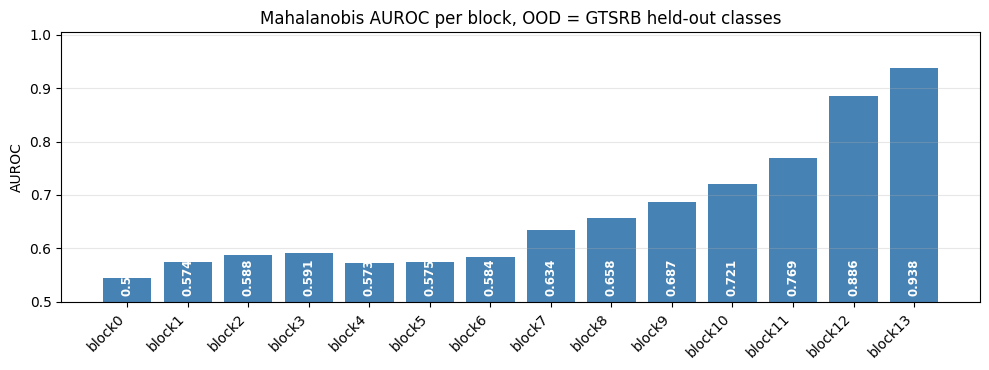

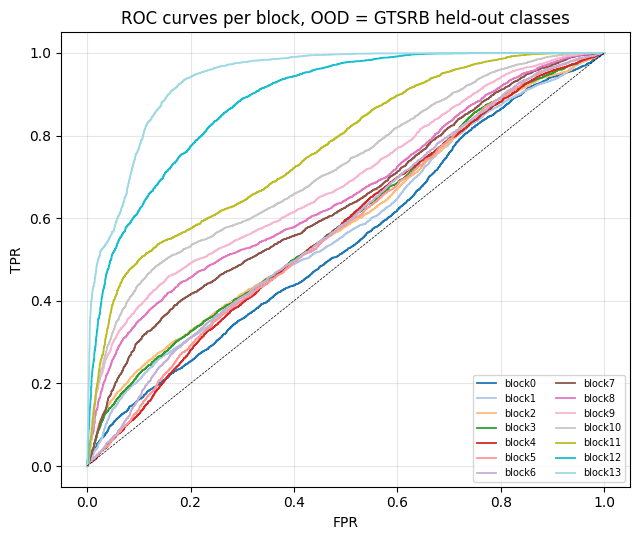

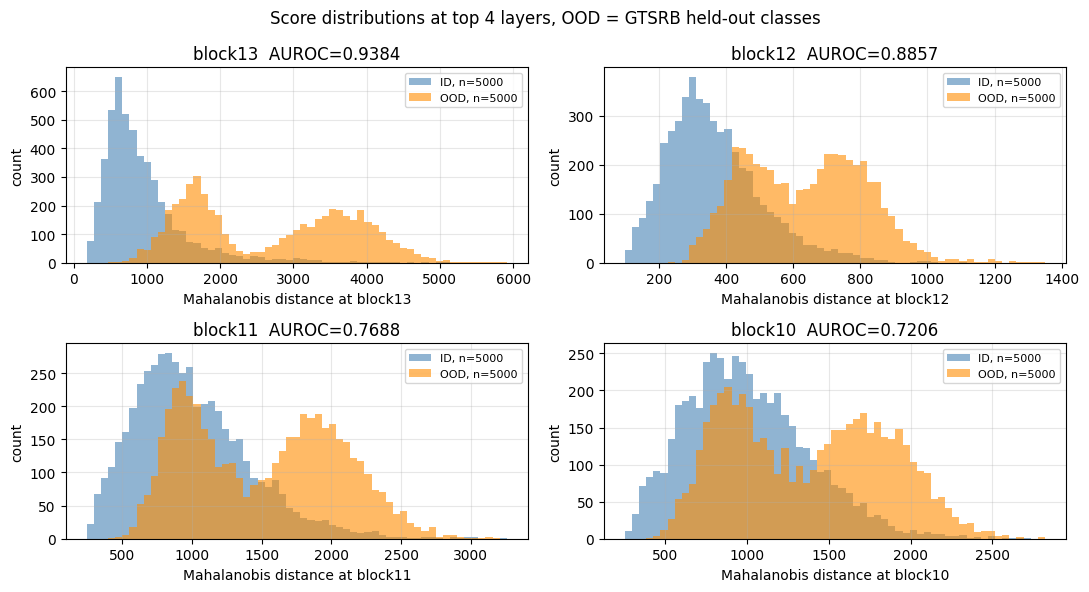

In [24]:
near_result = analyze_ood_source(holdout_ood_ds, "gtsrb_holdout", "GTSRB held-out classes")

  FGSM tune  tag=kept  eps=0.005  n=1000

Multi-layer combination, OOD = GTSRB held-out
method                          AUROC   TNR@95   DetAcc
best single (block13)         0.9384   0.5674   0.8736
mean_z (stage)                0.7572   0.3896   0.6794
mean_z (all)                  0.7099   0.3080   0.6488
uniform_sum (stage)           0.7572   0.3896   0.6794
logreg_fgsm (all)             0.9503   0.6806   0.9004


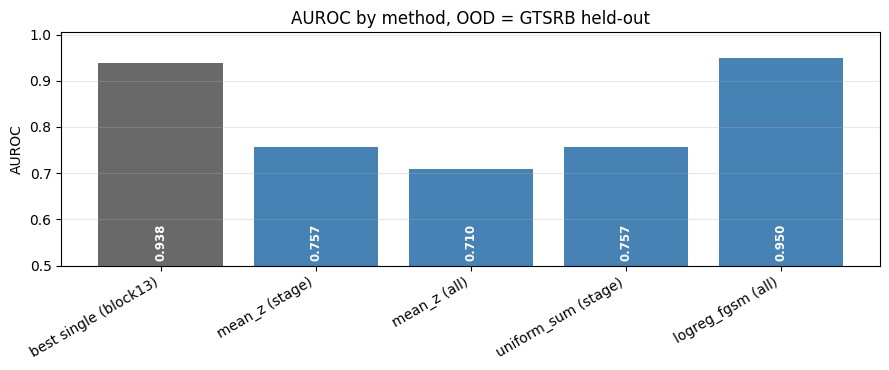

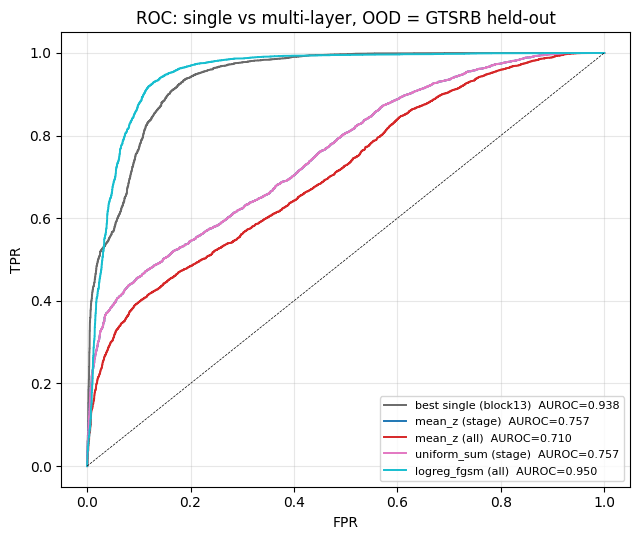

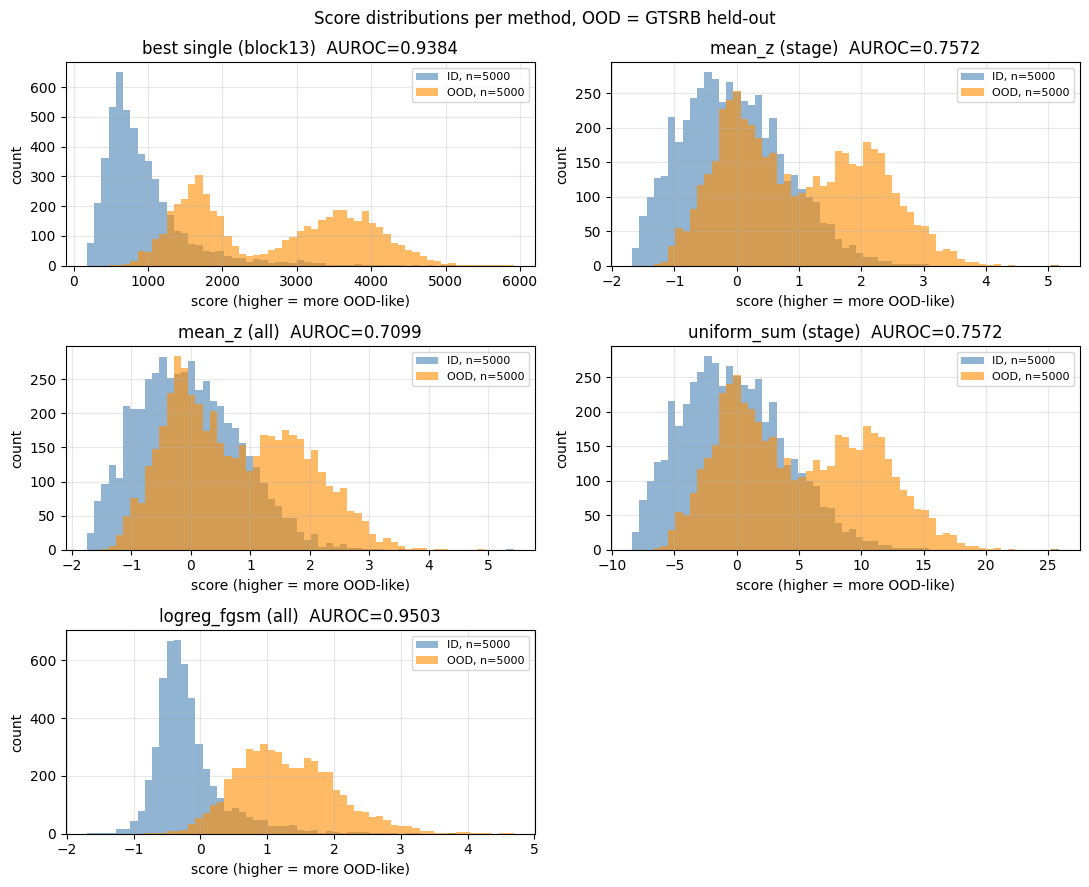

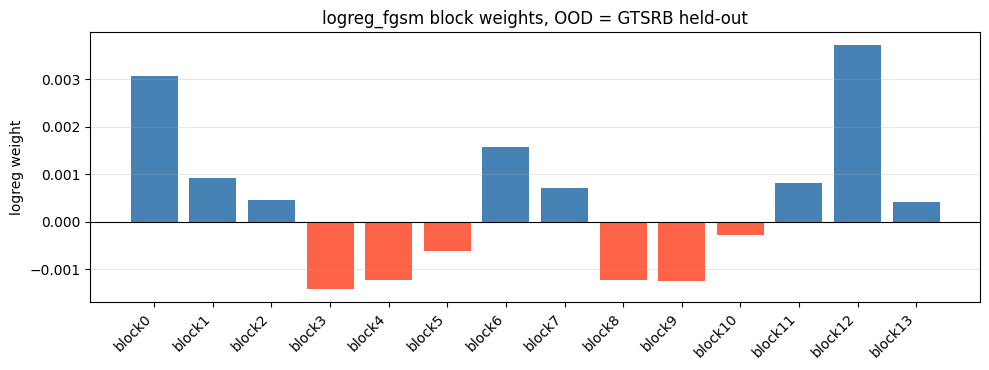

{'rows': [('best single (block13)', 0.93838768, 0.5674, 0.8735999999999999),
  ('mean_z (stage)', 0.75724524, 0.3896, 0.6794),
  ('mean_z (all)', 0.70994, 0.308, 0.6488),
  ('uniform_sum (stage)', 0.75724524, 0.3896, 0.6794),
  ('logreg_fgsm (all)', 0.9502738800000001, 0.6806, 0.9004)],
 'scores': [('best single (block13)',
   array([1621.79821839,  547.14969809, 1489.87742865, ...,  249.08805261,
           689.27289808,  399.04382762]),
   array([1916.83811963, 1290.68435934, 3990.31057293, ..., 3881.85562843,
          3339.6817951 , 3442.20255657]),
   0.93838768),
  ('mean_z (stage)',
   array([ 0.34577711, -0.47963497,  0.64433929, ..., -1.62913088,
           0.23554361, -0.59868306]),
   array([ 1.94315741, -0.83271811,  1.74980896, ...,  2.03161769,
           1.00703184,  0.75539493]),
   0.75724524),
  ('mean_z (all)',
   array([ 0.14183894, -0.54983393,  0.78916532, ..., -1.6935025 ,
           0.31220853, -0.63799866]),
   array([ 2.11248725, -0.92435999,  1.41640493, ...,

In [25]:
analyze_combined(near_result, "GTSRB held-out", tag="kept")

  load  fgsm_kept.npz

Multi-layer combination, OOD = GTSRB held-out
method                          AUROC   TNR@95   DetAcc
best single (block13)         0.9384   0.5674   0.8736
mean_z (stage)                0.7572   0.3896   0.6794
mean_z (all)                  0.7099   0.3080   0.6488
uniform_sum (stage)           0.7572   0.3896   0.6794
logreg_fgsm (all)             0.9503   0.6806   0.9004
mean_z (custom, 2)            0.9214   0.5544   0.8432
logreg_fgsm (custom, 2)       0.9398   0.5706   0.8768


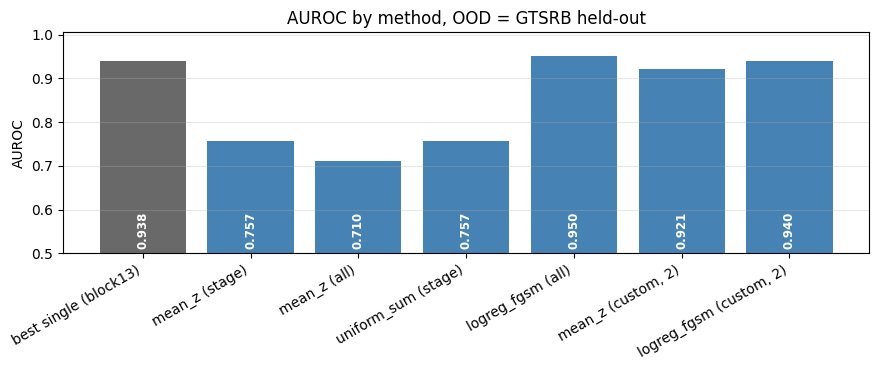

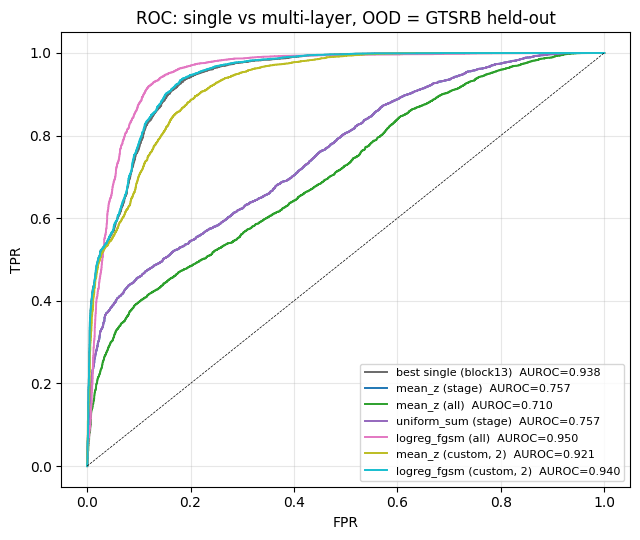

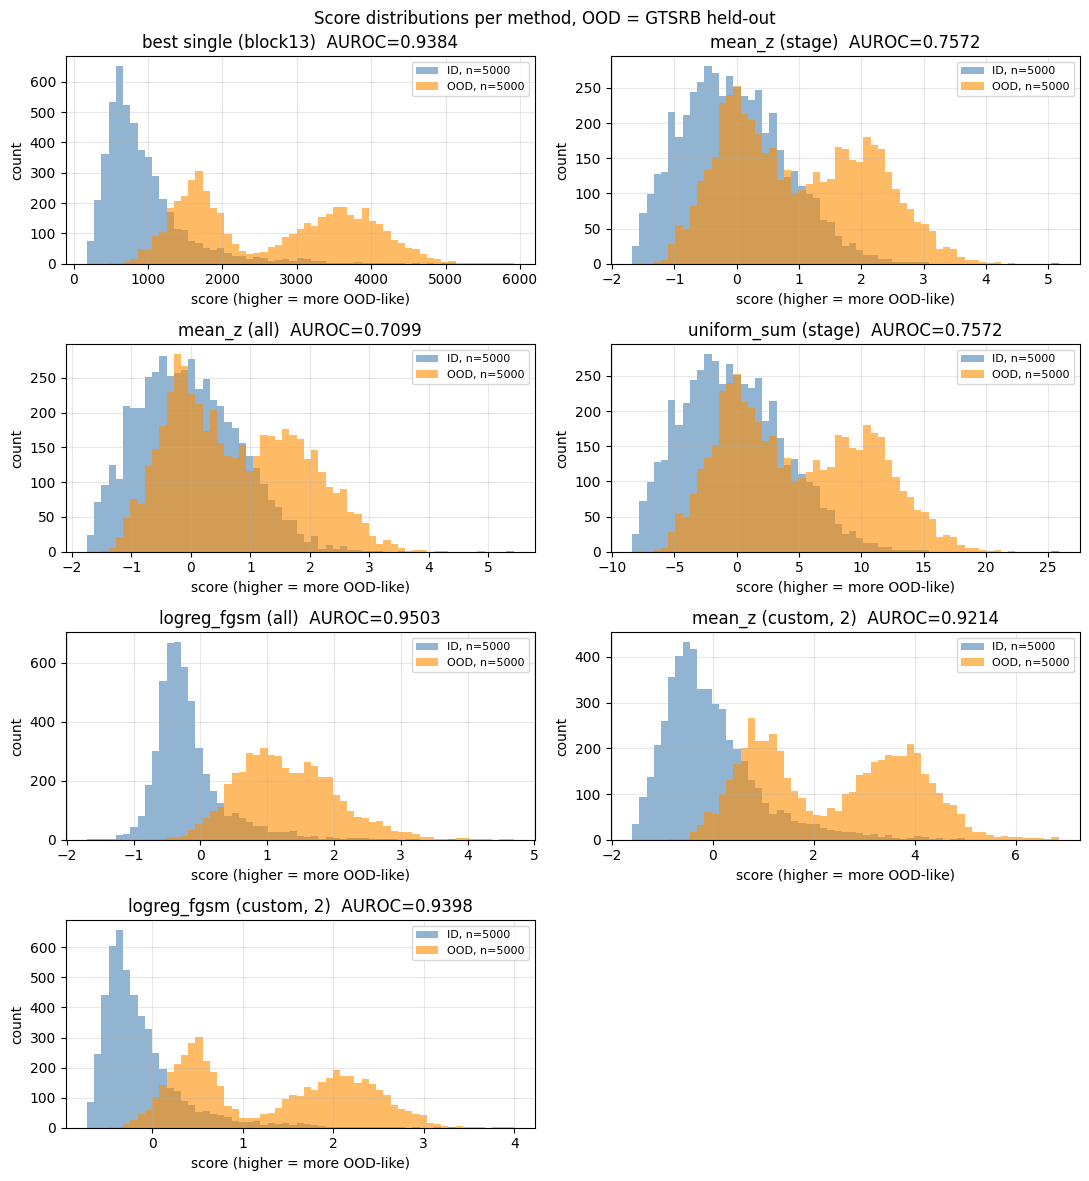

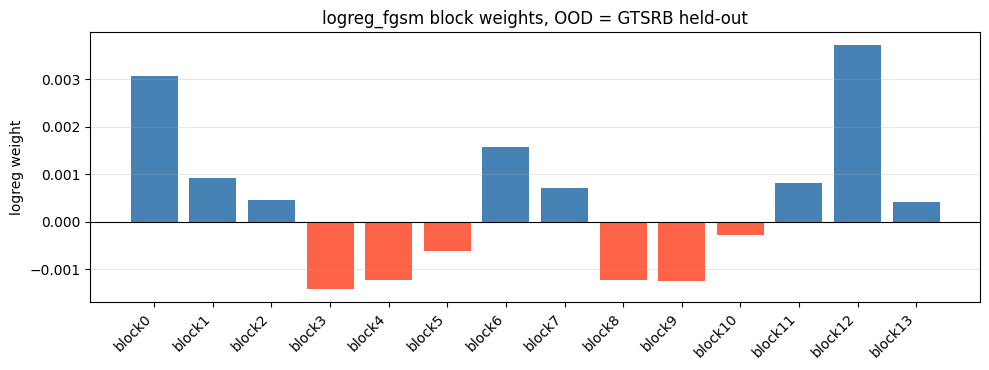

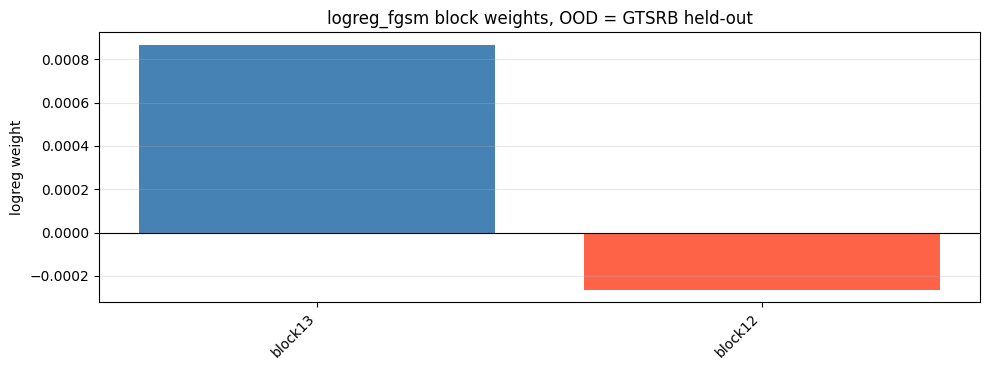

{'rows': [('best single (block13)', 0.93838768, 0.5674, 0.8735999999999999),
  ('mean_z (stage)', 0.75724524, 0.3896, 0.6794),
  ('mean_z (all)', 0.70994, 0.308, 0.6488),
  ('uniform_sum (stage)', 0.75724524, 0.3896, 0.6794),
  ('logreg_fgsm (all)', 0.9502738800000001, 0.6806, 0.9004),
  ('mean_z (custom, 2)', 0.9214052800000001, 0.5544, 0.8432),
  ('logreg_fgsm (custom, 2)', 0.9398404000000001, 0.5706, 0.8768)],
 'scores': [('best single (block13)',
   array([1621.79821839,  547.14969809, 1489.87742865, ...,  249.08805261,
           689.27289808,  399.04382762]),
   array([1916.83811963, 1290.68435934, 3990.31057293, ..., 3881.85562843,
          3339.6817951 , 3442.20255657]),
   0.93838768),
  ('mean_z (stage)',
   array([ 0.34577711, -0.47963497,  0.64433929, ..., -1.62913088,
           0.23554361, -0.59868306]),
   array([ 1.94315741, -0.83271811,  1.74980896, ...,  2.03161769,
           1.00703184,  0.75539493]),
   0.75724524),
  ('mean_z (all)',
   array([ 0.14183894, -0.549

In [26]:
top2 = sorted(LAYER_NAMES, key=lambda n: near_result["per_layer"][n]["auroc"], reverse=True)[:2]
analyze_combined(near_result, "GTSRB held-out", tag="kept", custom_layers=top2)